# Project Execution Guide

Before running the notebook, update the `file_path` (IN CELL 3) variable so it matches the location of your local `data1` file.

Example:

```python
file_path = "C:/Users/your_name/Documents/data1.csv"
```

Once the file path is configured, run all notebook cells sequentially from top to bottom.

The notebook will generate:
- Cointegration analysis results
- Pair selection outputs
- Sector-by-sector statistical arbitrage strategies
- Dynamic hedge ratios using the Kalman Filter
- Spread and z-score calculations
- Strategy backtesting and performance metrics

Required Python packages:
- pandas
- numpy
- statsmodels
- pykalman
- matplotlib
- seaborn
- itertools

In [1]:
"""
Commodity Pairs Finder — Cointegration Scores
Step 1 of a Kalman Filter pairs trading strategy.

Assets : Energy-focused (oil, gas, refiners…)
Output  : Cointegration score heatmap + ranked table
"""

import warnings; warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from itertools import combinations
from statsmodels.tsa.stattools import coint
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from pykalman import KalmanFilter


In [2]:
## Plotting function

DARK  = "#0f1117";  PANEL = "#1a1d2e"
GOLD  = "#f0c040";  CYAN  = "#4ecdc4"
RED   = "#e05c5c";  WHITE = "#e8e8e8";  GREY = "#555566"

def style(ax, title):
        ax.set_facecolor(PANEL)
        ax.set_title(title, color=GOLD, fontsize=10, fontweight="bold", pad=6)
        ax.tick_params(colors=WHITE, labelsize=8)
        for sp in ax.spines.values(): sp.set_color(GREY)
        ax.xaxis.label.set_color(WHITE)
        ax.yaxis.label.set_color(WHITE)

In [ ]:
import pandas as pd
import numpy as np

#To modify and adapt to your path
file_path = r"...data1.xlsx"

df = pd.read_excel(file_path, sheet_name="bloomberg_data")

# Rename + parse date
df = df.rename(columns={df.columns[0]: "Date"})
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df = df.dropna(subset=["Date"]).set_index("Date").sort_index()

# KEEP ONLY NUMERIC DATA
df = df.apply(pd.to_numeric, errors="coerce")

# Drop all-empty columns
df = df.dropna(axis=1, how="all")

raw = df
print(raw.tail())

               CL1     CO1     HO1     XB1    NG1     GC1     SI1     HG1  \
Date                                                                        
2026-03-25   90.32  102.22  400.63  301.24  2.952  4552.3  72.361  552.90   
2026-03-26   94.48  108.01  427.34  313.02  2.999  4376.3  67.671  544.65   
2026-03-27   99.64  112.57  449.55  325.01  3.095  4492.5  69.545  546.70   
2026-03-30  102.88  112.78  436.43  335.15  2.887  4526.0  70.569  550.20   
2026-03-31  101.38  118.35  416.34  331.23  2.884  4647.6  74.919  561.40   

                C1      W1       S1    SM1    SO1     KC1    SB1  
Date                                                              
2026-03-25  467.25  597.75  1171.75  319.8  67.10  316.10  15.55  
2026-03-26  467.00  605.00  1173.75  322.1  68.02  307.65  15.87  
2026-03-27  462.00  605.00  1159.25  315.3  67.41  301.70  15.76  
2026-03-30  455.75  607.00  1159.75  314.9  68.47  292.55  15.55  
2026-03-31  457.75  616.25  1171.00  316.4  68.88  298.35 

In [26]:
import numpy as np
import pandas as pd
from itertools import combinations
from statsmodels.tsa.stattools import coint

# -------------------------------------------------
# 1. CLEAN DATA
# -------------------------------------------------
prices = raw.copy()
prices = prices.replace([np.inf, -np.inf], np.nan)

# forward/back fill to handle missing trading days
prices = prices.ffill().bfill()
prices = prices.dropna()

# ensure strictly positive (required for log)
prices = prices.where(prices > 0)
prices = prices.ffill().bfill()


# -------------------------------------------------
# 2. TRANSFORM (LOG PRICES)
# -------------------------------------------------
log_px = np.log(prices)

# final safety cleanup
log_px = log_px.replace([np.inf, -np.inf], np.nan).dropna()


# -------------------------------------------------
# 3. DEFINE ECONOMIC GROUPS
# -------------------------------------------------
energy = ["CL1", "CO1", "HO1", "XB1", "NG1"]

metals = ["GC1", "SI1", "HG1"]

agri = ["C1", "W1", "S1", "SM1", "SO1", "KC1", "SB1"]

groups = {
    "Energy": energy,
    "Metals": metals,
    "Agriculture": agri
}


# -------------------------------------------------
# 4. COINTEGRATION FUNCTION
# -------------------------------------------------
def run_cointegration(df):
    results = []

    for a, b in combinations(df.columns, 2):

        pair = df[[a, b]].dropna()

        # skip short or degenerate series
        if len(pair) < 200:
            continue

        if pair.iloc[:, 0].std() < 1e-8 or pair.iloc[:, 1].std() < 1e-8:
            continue

        try:
            _, pval, _ = coint(pair[a], pair[b])

            results.append({
                "Pair": f"{a} / {b}",
                "p-value": pval,
                "Score": 1 - pval
            })

        except:
            continue

    return pd.DataFrame(results).sort_values("p-value")


# -------------------------------------------------
# 5. RUN BY GROUP
# -------------------------------------------------
results_all = {}

for name, cols in groups.items():

    cols = [c for c in cols if c in log_px.columns]

    if len(cols) < 2:
        continue

    print(f"\nRunning cointegration: {name}")
    print(f"Assets: {len(cols)}")

    df_group = log_px[cols]

    results_all[name] = run_cointegration(df_group)


# -------------------------------------------------
# 6. DISPLAY RESULTS
# -------------------------------------------------
for name, df_res in results_all.items():

    print("\n" + "="*60)
    print(f"{name} - Top Cointegrated Pairs")
    print("="*60)

    print(df_res.head(20).to_string(index=False))


Running cointegration: Energy
Assets: 5

Running cointegration: Metals
Assets: 3

Running cointegration: Agriculture
Assets: 7

Energy - Top Cointegrated Pairs
     Pair      p-value    Score
CL1 / CO1 9.289838e-09 1.000000
CO1 / XB1 9.346286e-08 1.000000
CO1 / HO1 5.061769e-06 0.999995
HO1 / XB1 7.627502e-06 0.999992
CL1 / XB1 1.019107e-04 0.999898
XB1 / NG1 2.773930e-03 0.997226
CL1 / NG1 3.423268e-03 0.996577
CL1 / HO1 1.313793e-02 0.986862
CO1 / NG1 1.256049e-01 0.874395
HO1 / NG1 2.613874e-01 0.738613

Metals - Top Cointegrated Pairs
     Pair  p-value    Score
SI1 / HG1 0.251103 0.748897
GC1 / SI1 0.372646 0.627354
GC1 / HG1 0.729648 0.270352

Agriculture - Top Cointegrated Pairs
     Pair  p-value    Score
 W1 / SO1 0.000581 0.999419
  C1 / W1 0.008444 0.991556
  W1 / S1 0.010219 0.989781
 W1 / KC1 0.019726 0.980274
 W1 / SM1 0.020047 0.979953
 W1 / SB1 0.022929 0.977071
 C1 / SO1 0.024347 0.975653
  C1 / S1 0.027146 0.972854
 C1 / SB1 0.027527 0.972473
SM1 / SB1 0.029635 0.970

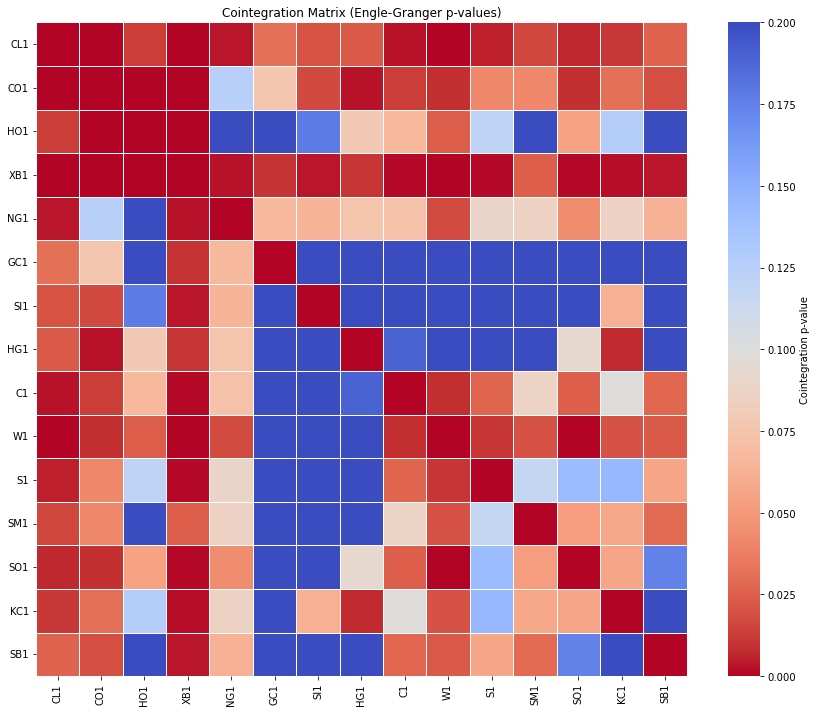

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import coint
from itertools import combinations

# -------------------------------------------------
# 1. USE CLEAN DATA (log prices)
# -------------------------------------------------
data = log_px.copy()

assets = data.columns.tolist()

# -------------------------------------------------
# 2. BUILD P-VALUE MATRIX
# -------------------------------------------------
pval_matrix = pd.DataFrame(np.ones((len(assets), len(assets))),
                        index=assets, columns=assets)

for i, a in enumerate(assets):
    for j, b in enumerate(assets):

        if i >= j:
            continue

        pair = data[[a, b]].dropna()

        if len(pair) < 200:
            continue

        try:
            _, pval, _ = coint(pair[a], pair[b])

            pval_matrix.loc[a, b] = pval
            pval_matrix.loc[b, a] = pval

        except:
            continue

# diagonal = 0 (perfect self-correlation conceptually)
np.fill_diagonal(pval_matrix.values, 0)


# -------------------------------------------------
# 3. PLOT HEATMAP
# -------------------------------------------------
plt.figure(figsize=(12, 10))

sns.heatmap(
    pval_matrix,
    cmap="coolwarm_r",
    vmin=0, vmax=0.2,   # focus on meaningful range
    linewidths=0.5,
    cbar_kws={"label": "Cointegration p-value"}
)

plt.title("Cointegration Matrix (Engle-Granger p-values)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [27]:
import pandas as pd


# -------------------------------------------------
# 2. BEST PAIR FUNCTION (FILTER pval > 0)
# -------------------------------------------------
def best_pair(group_cols):
    best = (None, None, 1.0)

    for i in range(len(group_cols)):
        for j in range(i + 1, len(group_cols)):

            a = group_cols[i]
            b = group_cols[j]

            if a not in pval_matrix.columns or b not in pval_matrix.columns:
                continue

            pval = pval_matrix.loc[a, b]

            # ❌ exclude invalid or degenerate results
            if pd.isna(pval) or pval <= 0.000001:
                continue

            if pval < best[2]:
                best = (a, b, pval)

    return best

# -------------------------------------------------
# 3. PRINT RESULTS
# -------------------------------------------------
print("\n" + "="*60)
print("TOP 1 COINTEGRATED PAIR PER CATEGORY (CLEAN)")
print("="*60)

for name, cols in groups.items():

    a, b, pval = best_pair(cols)

    print(f"\n{name}")

    if a is None:
        print("No valid pair found (after filtering)")
    else:
        print(f"{a}  vs  {b}")
        print(f"p-value: {pval:.6f}")


TOP 1 COINTEGRATED PAIR PER CATEGORY (CLEAN)

Energy
CO1  vs  HO1
p-value: 0.000005

Metals
SI1  vs  HG1
p-value: 0.251103

Agriculture
W1  vs  SO1
p-value: 0.000581


**Energy Sector**

In [28]:
# 2. LOG PRICES
log_px = np.log(prices)

# Convention:
# y = HeatingOil (dependent)
# x = Gasoline (independent)

y = log_px["CO1"]
x = log_px["HO1"]

# 3. OLS #1 — INITIALIZATION (last 2 years)

cutoff = log_px.index.max() - pd.DateOffset(years=2)

# Align + clean
data = pd.concat([y, x], axis=1)
data.columns = ["y", "x"]

# Keep only last 2 years
data = data.loc[cutoff:]

# Remove NaN / inf
data = data.replace([np.inf, -np.inf], np.nan).dropna()

y_init = data["y"]
x_init = data["x"]

X_init = add_constant(x_init)

ols_init = OLS(y_init, X_init).fit()

alpha_init = ols_init.params.iloc[0]
beta_init  = ols_init.params.iloc[1]

print("=" * 60)
print("OLS #1 — Last 2 Years (initialization for Kalman)")
print("=" * 60)
print(f"Window:    {cutoff.date()} to {log_px.index.max().date()}")
print(f"alpha:     {alpha_init:.6f}")
print(f"beta:      {beta_init:.6f}")
print(f"R-squared: {ols_init.rsquared:.4f}")

OLS #1 — Last 2 Years (initialization for Kalman)
Window:    2024-03-31 to 2026-03-31
alpha:     0.722390
beta:      0.651523
R-squared: 0.4743


In [29]:
# 4. OLS #2 — FULL-SAMPLE BENCHMARK (2006–2026)
X_full = add_constant(x)
ols_full = OLS(y, X_full).fit()

alpha_full = ols_full.params.iloc[0]
beta_full  = ols_full.params.iloc[1]

print("=" * 60)
print("OLS #2 — Full Sample (static benchmark)")
print("=" * 60)
print(f"Window:    {log_px.index.min().date()} to {log_px.index.max().date()}")
print(f"alpha:     {alpha_full:.6f}")
print(f"beta:      {beta_full:.6f}")
print(f"R-squared: {ols_full.rsquared:.4f}")
print()

OLS #2 — Full Sample (static benchmark)
Window:    2005-12-30 to 2026-03-31
alpha:     0.326321
beta:      0.738491
R-squared: 0.5199



In [31]:
# -------------------------------------------------
# 5. KALMAN FILTER — TIME-VARYING (alpha_t, beta_t)
# NO LOOK-AHEAD BIAS VERSION
# -------------------------------------------------
# State vector: [alpha_t, beta_t]^T
# Observation:  y_t = [1, x_t] * [alpha_t, beta_t]^T + noise

n = len(y)
BURN_IN = 252  # 1 year of trading to initialize the filter
DELTA = 5e-7   
OBS_VAR = 1e-3 

# 1. BURN-IN : OLS Calibration
x_burn = x.iloc[:BURN_IN]
y_burn = y.iloc[:BURN_IN]
X_burn_const = add_constant(x_burn)

ols_seed = OLS(y_burn, X_burn_const).fit()
alpha_init = ols_seed.params.iloc[0]
beta_init  = ols_seed.params.iloc[1]

print(f"Burn-in OLS seed ({BURN_IN} bars): alpha_0 = {alpha_init:.4f}, beta_0 = {beta_init:.4f}")

# 2. CONFIGURATION
obs_mat = np.vstack([np.ones(n), x.values]).T[:, np.newaxis, :]
trans_cov = DELTA / (1 - DELTA) * np.eye(2)

kf = KalmanFilter(
    n_dim_obs=1,
    n_dim_state=2,
    initial_state_mean=[alpha_init, beta_init],
    initial_state_covariance=np.ones((2, 2)) * 0.01,
    transition_matrices=np.eye(2),
    observation_matrices=obs_mat,
    observation_covariance=[[OBS_VAR]],
    transition_covariance=trans_cov,
)

state_means, state_covs = kf.filter(y.values)

alpha_kf = pd.Series(state_means[:, 0], index=y.index, name="alpha_kf").astype(float)
beta_kf  = pd.Series(state_means[:, 1], index=y.index, name="beta_kf").astype(float)

alpha_kf.iloc[:BURN_IN] = np.nan
beta_kf.iloc[:BURN_IN] = np.nan

# -------------------------------------------------
# SUMMARY
# -------------------------------------------------
print("=" * 60)
print("Kalman Filter — Summary of beta(t) (Out-of-Sample)")
print("=" * 60)
print(f"First live beta: {beta_kf.dropna().iloc[0]:.6f}   (post burn-in)")
print(f"Final beta:      {beta_kf.iloc[-1]:.6f}")
print(f"Min beta:        {beta_kf.min():.6f}  on {beta_kf.idxmin().date() if hasattr(beta_kf.index, 'date') else beta_kf.idxmin()}")
print(f"Max beta:        {beta_kf.max():.6f}  on {beta_kf.idxmax().date() if hasattr(beta_kf.index, 'date') else beta_kf.idxmax()}")
print(f"Mean beta:       {beta_kf.mean():.6f}")
print()

Burn-in OLS seed (252 bars): alpha_0 = 8.6181, beta_0 = -0.8546
Kalman Filter — Summary of beta(t) (Out-of-Sample)
First live beta: -0.852384   (post burn-in)
Final beta:      -0.356970
Min beta:        -0.982670  on 2016-01-22
Max beta:        -0.356970  on 2026-03-31
Mean beta:       -0.700937



In [32]:

# -------------------------------------------------
# 6. SPREADS + Z-SCORE
# -------------------------------------------------
spread_kf  = y - (alpha_kf + beta_kf * x)
spread_ols = y - (alpha_full + beta_full * x)

# Rolling z-score of Kalman spread
WINDOW = 252           # 1 trading year
THRESHOLD = 2.0

spread_mean = spread_kf.rolling(WINDOW).mean()
spread_std  = spread_kf.rolling(WINDOW).std()
zscore      = (spread_kf - spread_mean) / spread_std

short_signal = zscore >  THRESHOLD
long_signal  = zscore < -THRESHOLD

print("=" * 60)
print("Spread Statistics")
print("=" * 60)
print(f"Static OLS spread -- mean: {spread_ols.mean():+.4f}, std: {spread_ols.std():.4f}")
print(f"Kalman spread     -- mean: {spread_kf.mean():+.4f}, std: {spread_kf.std():.4f}")
print()
print("=" * 60)
print(f"Trading Signals (|z| > {THRESHOLD})")
print("=" * 60)
print(f"Total observations:    {len(zscore.dropna())}")
print(f"Short signals (z>+2):  {short_signal.sum()}  ({100*short_signal.mean():.2f}% of days)")
print(f"Long signals  (z<-2):  {long_signal.sum()}   ({100*long_signal.mean():.2f}% of days)")
print()


Spread Statistics
Static OLS spread -- mean: +0.0000, std: 0.2201
Kalman spread     -- mean: +0.0010, std: 0.0553

Trading Signals (|z| > 2.0)
Total observations:    4610
Short signals (z>+2):  112  (2.19% of days)
Long signals  (z<-2):  210   (4.11% of days)



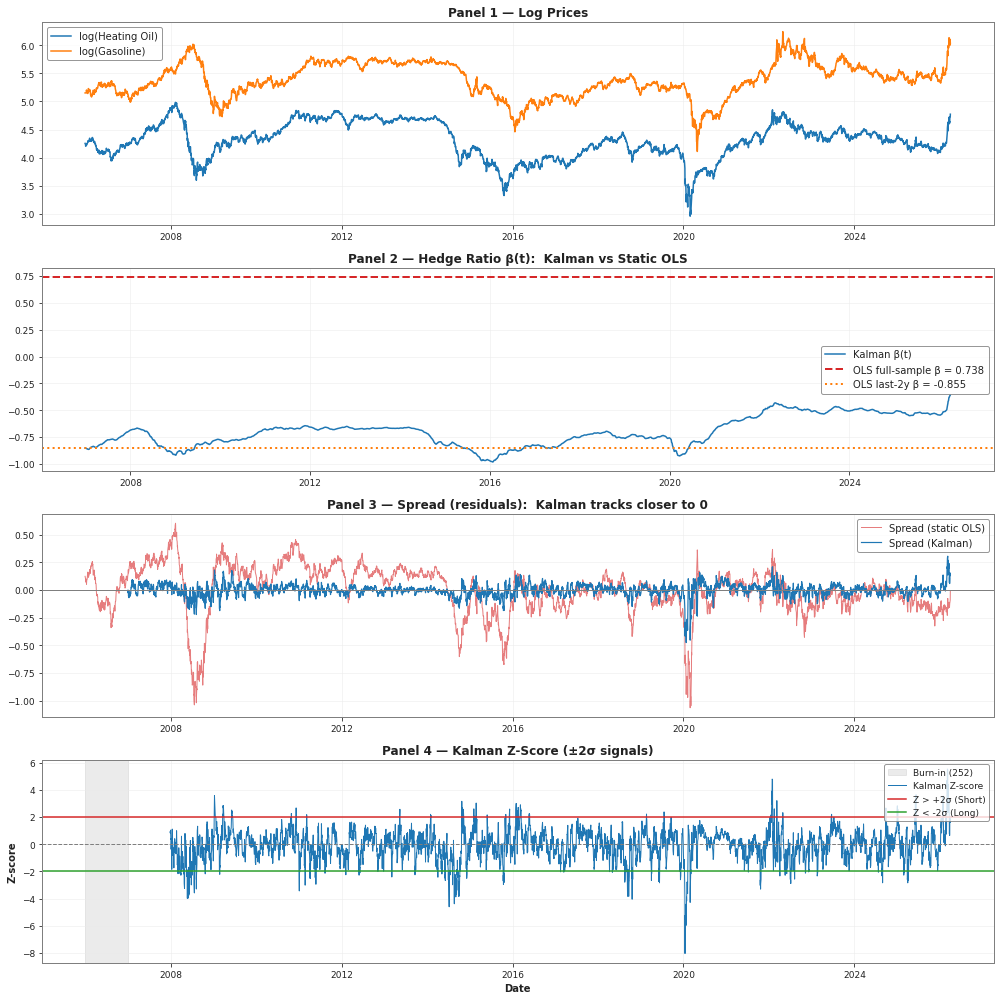

In [33]:
# -------------------------------------------------
# 7. PLOTS — 4 PANELS
# -------------------------------------------------
import matplotlib.pyplot as plt


BG_WHITE = "#FFFFFF"
TEXT_BLACK = "#222222"
MAIN_BLUE = "#1F77B4"    
ACCENT_ORANGE = "#FF7F0E"  
ALERT_RED = "#D62728"    
SAFE_GREEN = "#2CA02C"   
GRID_GRAY = "#EAEAEA"    
LINE_GRAY = "#7F7F7F"    

fig, axes = plt.subplots(4, 1, figsize=(14, 14), facecolor=BG_WHITE)

# --- Panel 1: log prices
ax = axes[0]
ax.plot(y.index.to_numpy(), y.values, color=MAIN_BLUE, lw=1.5, label="log(Heating Oil)")
ax.plot(x.index.to_numpy(), x.values, color=ACCENT_ORANGE, lw=1.5, label="log(Gasoline)")
ax.set_title("Panel 1 — Log Prices", color=TEXT_BLACK, fontweight="bold")
ax.legend(facecolor=BG_WHITE, edgecolor=LINE_GRAY, labelcolor=TEXT_BLACK)

# --- Panel 2: Kalman beta(t) vs static OLS
ax = axes[1]
ax.plot(beta_kf.index.to_numpy(), beta_kf.values, color=MAIN_BLUE, lw=1.5, label="Kalman β(t)")
ax.axhline(beta_full, color=ALERT_RED, ls="--", lw=2.0,
        label=f"OLS full-sample β = {beta_full:.3f}")
ax.axhline(beta_init, color=ACCENT_ORANGE, ls=":", lw=2.0,
        label=f"OLS last-2y β = {beta_init:.3f}")
ax.set_title("Panel 2 — Hedge Ratio β(t):  Kalman vs Static OLS",
        color=TEXT_BLACK, fontweight="bold")
ax.legend(facecolor=BG_WHITE, edgecolor=LINE_GRAY, labelcolor=TEXT_BLACK)

# --- Panel 3: spreads
ax = axes[2]
ax.plot(spread_ols.index.to_numpy(), spread_ols.values, color=ALERT_RED, lw=1.0, alpha=0.6,
        label="Spread (static OLS)")
ax.plot(spread_kf.index.to_numpy(), spread_kf.values, color=MAIN_BLUE, lw=1.2,
        label="Spread (Kalman)")
ax.axhline(0, color=LINE_GRAY, lw=1.0)
ax.set_title("Panel 3 — Spread (residuals):  Kalman tracks closer to 0",
        color=TEXT_BLACK, fontweight="bold")
ax.legend(facecolor=BG_WHITE, edgecolor=LINE_GRAY, labelcolor=TEXT_BLACK)

# --- Panel 4: Kalman Z-score with ±1.5σ trading signals
ax = axes[3]

burn_in_end = zscore.index[WINDOW] if len(zscore) > WINDOW else zscore.index[-1]


ax.axvspan(zscore.index[0], burn_in_end, color=LINE_GRAY, alpha=0.15,
        label=f"Burn-in ({WINDOW})")
ax.plot(zscore.index.to_numpy(), zscore.values, color=MAIN_BLUE, lw=1.0, label="Kalman Z-score")
ax.axhline( THRESHOLD, color=ALERT_RED,   lw=1.5, label="Z > +2σ (Short)")
ax.axhline(-THRESHOLD, color=SAFE_GREEN, lw=1.5, label="Z < -2σ (Long)")
ax.axhline(0, color=LINE_GRAY, ls="--", lw=1.0)
ax.set_title("Panel 4 — Kalman Z-Score (±2σ signals)",
        color=TEXT_BLACK, fontweight="bold")
ax.set_xlabel("Date", fontweight="bold")
ax.set_ylabel("Z-score", fontweight="bold")
ax.legend(facecolor=BG_WHITE, edgecolor=LINE_GRAY, labelcolor=TEXT_BLACK,
        loc="upper right", fontsize=9)

# Style all panels
for ax in axes:
        ax.set_facecolor(BG_WHITE)
        ax.tick_params(colors=TEXT_BLACK, labelsize=9)
        for sp in ax.spines.values(): 
                sp.set_color(LINE_GRAY)
                sp.set_linewidth(1.0)
        ax.xaxis.label.set_color(TEXT_BLACK)
        ax.yaxis.label.set_color(TEXT_BLACK)
        ax.grid(True, alpha=0.6, color=GRID_GRAY, linestyle="-")

plt.tight_layout()
#plt.savefig("kalman_output_presentation.png", dpi=300, facecolor=BG_WHITE, bbox_inches='tight')
plt.show()


  Long  entries : 91
  Short entries : 50
  Exits         : 140
  Total changes : 281


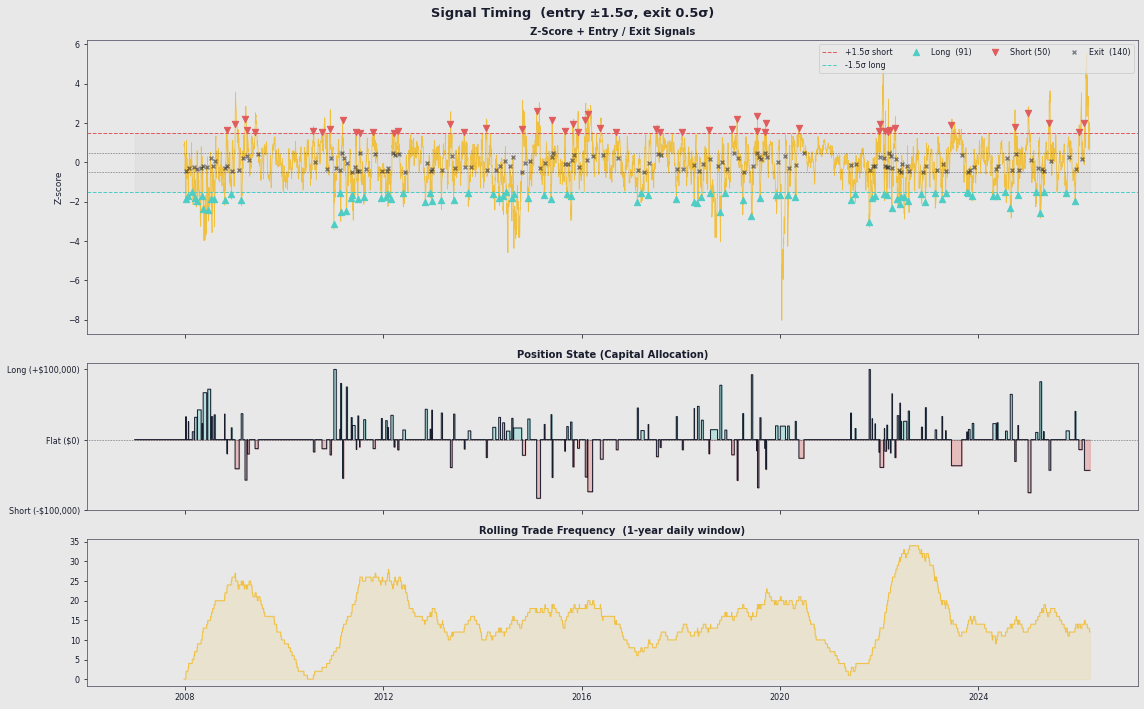

In [34]:
# ─────────────────────────────────────────────────────────────────────────────
#  PLOT 3 — Long / Short signals from Kalman z-score (Budget Scaled)
# ─────────────────────────────────────────────────────────────────────────────

# ── Signal parameters ─────────────────────────────────────────────────────────
ENTRY_Z = 1.5   # z-score threshold to enter a position
EXIT_Z  = 0.5   # z-score threshold to exit a position

# ── Slice to post-burn-in period (no look-ahead) ─────────────────────────────
zscore_kf  = zscore.iloc[BURN_IN:]

# CORRECTION ICI : On convertit immédiatement en tableaux NumPy 1D purs
dates_test = zscore.index[BURN_IN:].to_numpy()
z_arr = np.squeeze(zscore_kf.to_numpy())

# ── Position sizing — scaled by z-score magnitude & Budget ───────────────────
BUDGET = 100_000  # Total allocation capital
MAX_SIZE = 1.0    # maximum position fraction (1 = fully invested)
MIN_SIZE = 0.1    # minimum size once entry threshold is crossed

position = np.zeros(len(z_arr))
for i in range(1, len(z_arr)):
    prev = position[i-1]

    if np.isnan(z_arr[i]):
        continue

    if prev == 0:                                       # flat → look for entry
        if z_arr[i] > ENTRY_Z:
            raw_size = (z_arr[i] - ENTRY_Z) / ENTRY_Z
            fraction = np.clip(MIN_SIZE + raw_size, MIN_SIZE, MAX_SIZE)
            position[i] = -fraction * BUDGET            # short allocation
        elif z_arr[i] < -ENTRY_Z:
            raw_size = (-z_arr[i] - ENTRY_Z) / ENTRY_Z
            fraction = np.clip(MIN_SIZE + raw_size, MIN_SIZE, MAX_SIZE)
            position[i] = fraction * BUDGET             # long allocation
        else:
            position[i] = 0
    else:                                               # in position → look for exit
        if abs(z_arr[i]) < EXIT_Z:
            position[i] = 0                             # exit
        else:
            position[i] = prev                          # hold same dollar size

# ── Trade counting ────────────────────────────────────────────────────────────
changes = np.diff(position, prepend=0)

shifted_pos = np.roll(position, 1)
shifted_pos[0] = 0

is_long_entry  = (shifted_pos == 0) & (position > 0)
is_short_entry = (shifted_pos == 0) & (position < 0)
is_exit        = (shifted_pos != 0) & (position == 0)

long_entries  = np.where(is_long_entry)[0]
short_entries = np.where(is_short_entry)[0]
exits         = np.where(is_exit)[0]

print(f"  Long  entries : {len(long_entries)}")
print(f"  Short entries : {len(short_entries)}")
print(f"  Exits         : {len(exits)}")
print(f"  Total changes : {np.sum(changes != 0)}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True,
                        gridspec_kw={"height_ratios": [2, 1, 1]})
fig.patch.set_facecolor(WHITE)

# J'ai retiré T1 et T2 du titre si tu ne les as pas définis, sinon remets-les
fig.suptitle(f"Signal Timing  (entry ±{ENTRY_Z}σ, exit {EXIT_Z}σ)",
            color=PANEL, fontsize=13, fontweight="bold")

# — Panel 1 : z-score + markers —
ax1 = axes[0]
ax1.set_facecolor(WHITE)
ax1.plot(dates_test, z_arr, color=GOLD, lw=0.8, zorder=2)
ax1.axhline( ENTRY_Z, color=RED,  linestyle="--", lw=1.0, label=f"+{ENTRY_Z}σ short")
ax1.axhline(-ENTRY_Z, color=CYAN,  linestyle="--", lw=1.0, label=f"-{ENTRY_Z}σ long")
ax1.axhline( EXIT_Z,  color=PANEL, linestyle=":",  lw=0.6)
ax1.axhline(-EXIT_Z,  color=PANEL, linestyle=":",  lw=0.6)
ax1.fill_between(dates_test, -ENTRY_Z, ENTRY_Z, color=PANEL, alpha=0.03)

ax1.scatter(dates_test[long_entries],  z_arr[long_entries],
            color=CYAN, marker="^", s=40, zorder=3, label=f"Long  ({len(long_entries)})")
ax1.scatter(dates_test[short_entries], z_arr[short_entries],
            color=RED,  marker="v", s=40, zorder=3, label=f"Short ({len(short_entries)})")
ax1.scatter(dates_test[exits],         z_arr[exits],
            color=PANEL, marker="x", s=15, zorder=3, label=f"Exit  ({len(exits)})", alpha=0.5)

ax1.set_ylabel("Z-score", color=PANEL, fontsize=9)
ax1.tick_params(colors=PANEL, labelsize=8)
for sp in ax1.spines.values(): sp.set_color(GREY)
ax1.legend(fontsize=8, facecolor=WHITE, labelcolor=PANEL, ncol=4, loc="upper right")
ax1.set_title("Z-Score + Entry / Exit Signals", color=PANEL, fontsize=10, fontweight="bold", pad=5)

# — Panel 2 : position state —
ax2 = axes[1]
ax2.set_facecolor(WHITE)
ax2.plot(dates_test, position, color=PANEL, lw=1.0, drawstyle="steps-post")
pos_long  = np.where(position > 0, position, 0)
pos_short = np.where(position < 0, position, 0)
ax2.fill_between(dates_test, pos_long,  0, color=CYAN, alpha=0.3, step="post")
ax2.fill_between(dates_test, pos_short, 0, color=RED,  alpha=0.3, step="post")
ax2.axhline(0, color=PANEL, lw=0.6, linestyle=":")

ax2.set_yticks([-BUDGET, 0, BUDGET])
ax2.set_yticklabels([f"Short (-${BUDGET:,})", "Flat ($0)", f"Long (+${BUDGET:,})"], color=WHITE, fontsize=8)

ax2.tick_params(colors=PANEL, labelsize=8)
for sp in ax2.spines.values(): sp.set_color(GREY)
ax2.set_title("Position State (Capital Allocation)", color=PANEL, fontsize=10, fontweight="bold", pad=5)

# — Panel 3 : rolling trade count (daily data → 252-bar = 1 year) —
ax3 = axes[2]
ax3.set_facecolor(WHITE)

# On utilise index=dates_test qui est maintenant un array 1D
change_series  = pd.Series((changes != 0).astype(int))
rolling_trades = change_series.rolling(252).sum()          # 1 trading year (daily)

ax3.plot(dates_test, rolling_trades.to_numpy(), color=GOLD, lw=1.0)
ax3.fill_between(dates_test, rolling_trades.to_numpy(), color=GOLD, alpha=0.15)
ax3.set_ylabel("Trades / year", color=WHITE, fontsize=9)
ax3.tick_params(colors=PANEL, labelsize=8)
for sp in ax3.spines.values(): sp.set_color(GREY)
ax3.set_title("Rolling Trade Frequency  (1-year daily window)",
            color=PANEL, fontsize=10, fontweight="bold", pad=5)

plt.tight_layout()
plt.show()

════════════════════════════════════════════════════════════
  STRATEGY PERFORMANCE METRICS  (capital: $100,000)
════════════════════════════════════════════════════════════
  Total return           : -0.1533  →  $-15,334.54
  Annualised return      : -0.80%  →  $-795.12 / yr
  Annualised volatility  : 12.00%
  Sharpe ratio           : -0.0662
  Sortino ratio          : -0.0451
  Max drawdown           : -0.4498  →  $-44,980.54
  Time to recover MDD    : not recovered
────────────────────────────────────────────────────────────
  Total trades           : 141
  Long  trades           : 91  (64.5%)
  Short trades           : 50  (35.5%)
  Hit ratio              : 39.0%
  Profit factor          : 0.30
  Avg trade duration     : 9.0 days
────────────────────────────────────────────────────────────
  Transaction costs (1bp): 0.0281  →  $2,810.00  (18.3% of gross)
════════════════════════════════════════════════════════════


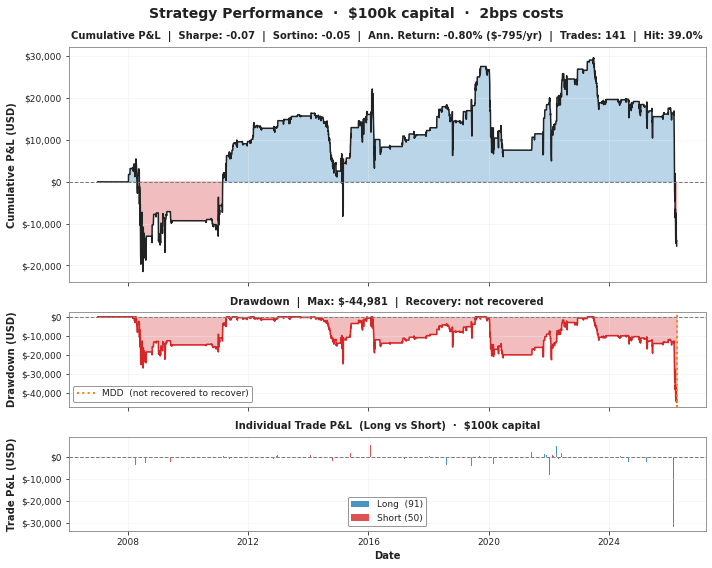

In [35]:
# ─────────────────────────────────────────────────────────────────────────────
#  PERFORMANCE METRICS  (daily data · $100,000 initial capital)
# ─────────────────────────────────────────────────────────────────────────────

INITIAL_CAPITAL = 100_000          # starting budget in USD

# ── Time index (post-burn-in, daily) ─────────────────────────────────────────
# dates_test and position already defined in Plot 3 cell
ANN            = 252               # annualisation factor for daily bars
COST_PER_TRADE = 0.0001            # 1 bps per side

# ── Transaction costs at every position change ────────────────────────────────
changes_arr       = np.diff(position, prepend=0)
changes_series    = pd.Series(changes_arr, index=dates_test)
transaction_costs = (changes_series != 0).astype(float) * COST_PER_TRADE

# ── Spread returns: position(t-1) × Δspread(t), net of costs ─────────────────
y_test = y[BURN_IN:]
x_test = x[BURN_IN:]

ret_y = np.diff(y_test, prepend=0)
ret_x = np.diff(x_test, prepend=0)

# Shift beta by 1 bar to avoid look-ahead (trade t with beta known at t-1)
beta_shifted    = np.roll(beta_kf, 1)
beta_shifted[0] = beta_kf[0]
beta_test       = beta_shifted[BURN_IN:]

true_port_ret  = ret_y - (beta_test * ret_x)

# On divise la position par INITIAL_CAPITAL pour revenir en % et éviter le capital au carré
position_weights = pd.Series(position, index=dates_test) / INITIAL_CAPITAL

strategy_ret   = position_weights.shift(1).fillna(0) * true_port_ret
strategy_ret   = strategy_ret - transaction_costs

# ── Cumulative PnL (log-return units + dollar equivalent) ────────────────────
cumulative_ret    = strategy_ret.cumsum()
cumulative_dollar = cumulative_ret * INITIAL_CAPITAL

# ── Annualised metrics ────────────────────────────────────────────────────────
total_return  = cumulative_ret.iloc[-1]
total_pnl     = total_return * INITIAL_CAPITAL

ann_return    = strategy_ret.mean() * ANN
ann_vol       = strategy_ret.std()  * np.sqrt(ANN)
ann_pnl       = ann_return * INITIAL_CAPITAL
sharpe        = ann_return / ann_vol if ann_vol > 0 else np.nan

downside      = strategy_ret[strategy_ret < 0]
downside_std  = downside.std() * np.sqrt(ANN)
sortino       = ann_return / downside_std if downside_std > 0 else np.nan

# ── Max drawdown ──────────────────────────────────────────────────────────────
roll_max     = cumulative_ret.cummax()
drawdown     = cumulative_ret - roll_max
max_drawdown = drawdown.min()
max_dd_pnl   = max_drawdown * INITIAL_CAPITAL
mdd_idx      = drawdown.idxmin()

mdd_pos       = cumulative_ret.index.get_loc(mdd_idx)
peak_val      = roll_max[mdd_idx]
recovery_bars = np.nan
for j in range(mdd_pos, len(cumulative_ret)):
    if cumulative_ret.iloc[j] >= peak_val:
        recovery_bars = j - mdd_pos
        break
recovery_str = f"{recovery_bars:.0f} days" if not np.isnan(recovery_bars) else "not recovered"

# ── Trade-level analysis ──────────────────────────────────────────────────────
trade_log = []
i = 0
while i < len(position):
    if position[i] != 0:
        entry_i   = i
        entry_dir = position[i]
        while i < len(position) and position[i] == entry_dir:
            i += 1
        exit_i    = i - 1
        trade_ret = strategy_ret.iloc[entry_i:exit_i+1].sum()
        trade_log.append({
            "direction": "long" if entry_dir > 0 else "short",
            "entry":     dates_test[entry_i],
            "exit":      dates_test[exit_i],
            "duration":  exit_i - entry_i + 1,
            "return":    trade_ret,
            "pnl":       trade_ret * INITIAL_CAPITAL,
        })
    else:
        i += 1

trades_df      = pd.DataFrame(trade_log)
n_trades       = len(trades_df)
n_long_trades  = (trades_df["direction"] == "long").sum()  if n_trades else 0
n_short_trades = (trades_df["direction"] == "short").sum() if n_trades else 0

winning_trades  = (trades_df["return"] > 0).sum() if n_trades else 0
hit_ratio       = winning_trades / n_trades * 100 if n_trades > 0 else np.nan
avg_duration    = trades_df["duration"].mean() if n_trades else np.nan

gross_profit    = trades_df[trades_df["return"] > 0]["return"].sum() if n_trades else 0
gross_loss      = abs(trades_df[trades_df["return"] < 0]["return"].sum()) if n_trades else 0
profit_factor   = gross_profit / gross_loss if gross_loss > 0 else np.nan
total_costs     = transaction_costs.sum()
total_costs_usd = total_costs * INITIAL_CAPITAL

# ── Print ─────────────────────────────────────────────────────────────────────
print("═" * 60)
print("  STRATEGY PERFORMANCE METRICS  (capital: $100,000)")
print("═" * 60)
print(f"  Total return           : {total_return:+.4f}  →  ${total_pnl:+,.2f}")
print(f"  Annualised return      : {ann_return:.2%}  →  ${ann_pnl:+,.2f} / yr")
print(f"  Annualised volatility  : {ann_vol:.2%}")
print(f"  Sharpe ratio           : {sharpe:.4f}")
print(f"  Sortino ratio          : {sortino:.4f}")
print(f"  Max drawdown           : {max_drawdown:.4f}  →  ${max_dd_pnl:+,.2f}")
print(f"  Time to recover MDD    : {recovery_str}")
print("─" * 60)
print(f"  Total trades           : {n_trades}")
print(f"  Long  trades           : {n_long_trades}  ({n_long_trades/n_trades*100:.1f}%)" if n_trades else "  Long  trades : 0")
print(f"  Short trades           : {n_short_trades}  ({n_short_trades/n_trades*100:.1f}%)" if n_trades else "  Short trades : 0")
print(f"  Hit ratio              : {hit_ratio:.1f}%")
print(f"  Profit factor          : {profit_factor:.2f}")
print(f"  Avg trade duration     : {avg_duration:.1f} days")
print("─" * 60)
tc_pct = total_costs / abs(total_return) * 100 if total_return != 0 else 0
print(f"  Transaction costs (1bp): {total_costs:.4f}  →  ${total_costs_usd:,.2f}  ({tc_pct:.1f}% of gross)")
print("═" * 60)

# ── Plot (PRESENTATION LIGHT THEME) ───────────────────────────────────────────

# Couleurs haut contraste pour la lisibilité
BG_WHITE = "#FFFFFF"
TEXT_BLACK = "#222222"
MAIN_BLUE = "#1F77B4"
ALERT_RED = "#D62728"
ACCENT_ORANGE = "#FF7F0E"
LINE_GRAY = "#7F7F7F"
GRID_GRAY = "#EAEAEA"

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True,
                        gridspec_kw={"height_ratios": [2.5, 1, 1]})
fig.patch.set_facecolor(BG_WHITE)
fig.suptitle(f"Strategy Performance  ·  $100k capital  ·  2bps costs",
            color=TEXT_BLACK, fontsize=14, fontweight="bold")

# — Panel 1 : Cumulative P&L in dollars —
ax1 = axes[0]
ax1.set_facecolor(BG_WHITE)
cd = cumulative_dollar.to_numpy()

ax1.plot(dates_test, cd, color=TEXT_BLACK, lw=1.5) # Ligne principale bien noire
ax1.fill_between(dates_test, cd, 0, where=(cd >= 0), color=MAIN_BLUE, alpha=0.3)
ax1.fill_between(dates_test, cd, 0, where=(cd <  0), color=ALERT_RED,  alpha=0.3)
ax1.axhline(0, color=LINE_GRAY, linestyle="--", lw=1.0)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:,.0f}"))
ax1.set_ylabel("Cumulative P&L (USD)", color=TEXT_BLACK, fontsize=10, fontweight="bold")
ax1.tick_params(colors=TEXT_BLACK, labelsize=9)
for sp in ax1.spines.values(): 
    sp.set_color(LINE_GRAY)
ax1.grid(True, alpha=0.5, color=GRID_GRAY)

ax1.set_title(
    f"Cumulative P&L  |  Sharpe: {sharpe:.2f}  |  Sortino: {sortino:.2f}  |  "
    f"Ann. Return: {ann_return:.2%} (${ann_pnl:+,.0f}/yr)  |  "
    f"Trades: {n_trades}  |  Hit: {hit_ratio:.1f}%",
    color=TEXT_BLACK, fontsize=10, fontweight="bold", pad=8)

# — Panel 2 : Drawdown in dollars —
ax2 = axes[1]
ax2.set_facecolor(BG_WHITE)
dd = (drawdown * INITIAL_CAPITAL).to_numpy()

ax2.fill_between(dates_test, dd, 0, color=ALERT_RED, alpha=0.3)
ax2.plot(dates_test, dd, color=ALERT_RED, lw=1.5)
ax2.axhline(0, color=LINE_GRAY, linestyle="--", lw=1.0)
ax2.axvline(mdd_idx, color=ACCENT_ORANGE, linestyle=":", lw=2.0,
            label=f"MDD  ({recovery_str} to recover)")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:,.0f}"))
ax2.set_ylabel("Drawdown (USD)", color=TEXT_BLACK, fontsize=10, fontweight="bold")
ax2.tick_params(colors=TEXT_BLACK, labelsize=9)
for sp in ax2.spines.values(): 
    sp.set_color(LINE_GRAY)
ax2.grid(True, alpha=0.5, color=GRID_GRAY)
ax2.legend(fontsize=9, facecolor=BG_WHITE, edgecolor=LINE_GRAY, labelcolor=TEXT_BLACK)

ax2.set_title(
    f"Drawdown  |  Max: ${max_dd_pnl:,.0f}  |  Recovery: {recovery_str}",
    color=TEXT_BLACK, fontsize=10, fontweight="bold", pad=8)

# — Panel 3 : Individual trade P&L in dollars —
ax3 = axes[2]
ax3.set_facecolor(BG_WHITE)
if n_trades:
    long_t  = trades_df[trades_df["direction"] == "long"]
    short_t = trades_df[trades_df["direction"] == "short"]
    ax3.bar(long_t["entry"],  long_t["pnl"],  color=MAIN_BLUE, width=4, alpha=0.8,
            label=f"Long  ({n_long_trades})")
    ax3.bar(short_t["entry"], short_t["pnl"], color=ALERT_RED,  width=4, alpha=0.8,
            label=f"Short ({n_short_trades})")
ax3.axhline(0, color=LINE_GRAY, linestyle="--", lw=1.0)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:,.0f}"))
ax3.set_ylabel("Trade P&L (USD)", color=TEXT_BLACK, fontsize=10, fontweight="bold")
ax3.set_xlabel("Date", color=TEXT_BLACK, fontsize=10, fontweight="bold")
ax3.tick_params(colors=TEXT_BLACK, labelsize=9)
for sp in ax3.spines.values(): 
    sp.set_color(LINE_GRAY)
ax3.grid(True, alpha=0.5, color=GRID_GRAY)
ax3.legend(fontsize=9, facecolor=BG_WHITE, edgecolor=LINE_GRAY, labelcolor=TEXT_BLACK)

ax3.set_title("Individual Trade P&L  (Long vs Short)  ·  $100k capital",
            color=TEXT_BLACK, fontsize=10, fontweight="bold", pad=8)

plt.tight_layout()
plt.show()

**Metal Sector**

In [36]:
from statsmodels.tsa.stattools import coint
# ------------------------------------------------------------
# 1. CLEAN METALS DATA
# ------------------------------------------------------------

metals_cols = ["SI1", "HG1"]

metals_prices = raw[metals_cols].copy()

metals_prices = metals_prices.replace([np.inf, -np.inf], np.nan)

# Use forward fill only to avoid look-ahead bias
metals_prices = metals_prices.ffill()
metals_prices = metals_prices.dropna()

# Keep only positive prices for log transformation
metals_prices = metals_prices[metals_prices > 0].dropna()

# Log prices
metals_log = np.log(metals_prices)

print(metals_log.head())
print(metals_log.tail())

                 SI1       HG1
Date                          
2006-01-04  2.184927  5.322278
2006-01-05  2.214846  5.345916
2006-01-06  2.215937  5.328119
2006-01-09  2.182900  5.340419
2006-01-10  2.216264  5.345678
                 SI1       HG1
Date                          
2026-03-25  4.281667  6.315177
2026-03-26  4.214658  6.300143
2026-03-27  4.241974  6.303900
2026-03-30  4.256591  6.310282
2026-03-31  4.316408  6.330434


In [37]:
# ------------------------------------------------------------
# 3. KALMAN FILTER FUNCTION
# ------------------------------------------------------------

def kalman_hedge_ratio(y, x):
    """
    Estimate dynamic intercept and hedge ratio using Kalman Filter.
    
    Model:
        y_t = alpha_t + beta_t * x_t + error_t
    """

    delta = 5e-6
    transition_covariance = delta / (1 - delta) * np.eye(2)

    observation_matrices = np.vstack([
        np.ones(len(x)),
        x.values
    ]).T[:, np.newaxis, :]

    kf = KalmanFilter(
        n_dim_obs=1,
        n_dim_state=2,
        initial_state_mean=np.zeros(2),
        initial_state_covariance=np.ones((2, 2)),
        transition_matrices=np.eye(2),
        observation_matrices=observation_matrices,
        observation_covariance=1.0,
        transition_covariance=transition_covariance
    )

    state_means, state_covariances = kf.filter(y.values)

    intercept = state_means[:, 0]
    beta = state_means[:, 1]

    return intercept, beta

In [39]:
# ------------------------------------------------------------
# 4. ESTIMATE DYNAMIC HEDGE RATIO
# ------------------------------------------------------------

# Keep only needed columns
metals_log = metals_log[["HG1", "SI1"]].copy()

# Remove NaN / inf
metals_log = (
    metals_log
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

# Define y and x AFTER cleaning
y = metals_log["HG1"]
x = metals_log["SI1"]

# Kalman hedge ratio
intercept, beta = kalman_hedge_ratio(y, x)

# Force aligned pandas Series
metals_log["intercept"] = pd.Series(intercept, index=metals_log.index)
metals_log["beta"] = pd.Series(beta, index=metals_log.index)

# ------------------------------------------------------------
# SPREAD
# ------------------------------------------------------------

metals_log["spread"] = (
    metals_log["HG1"]
    - metals_log["intercept"]
    - metals_log["beta"] * metals_log["SI1"]
)

# ------------------------------------------------------------
# 5. ROLLING Z-SCORE
# ------------------------------------------------------------

window = 60

metals_log["spread_mean"] = (
    metals_log["spread"]
    .rolling(window)
    .mean()
)

metals_log["spread_std"] = (
    metals_log["spread"]
    .rolling(window)
    .std()
)

metals_log["zscore"] = (
    metals_log["spread"] - metals_log["spread_mean"]
) / metals_log["spread_std"]

# Final cleanup
metals_log = metals_log.dropna()

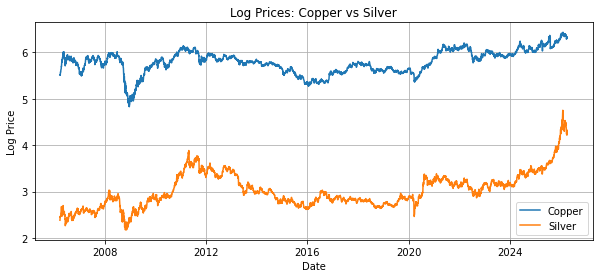

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# 9. PLOTS
# ------------------------------------------------------------

# Plot 1: Prices
plt.figure(figsize=(10, 4))
plt.plot(metals_log.index.to_numpy(), metals_log["HG1"].to_numpy(), label="Copper")
plt.plot(metals_log.index.to_numpy(), metals_log["SI1"].to_numpy(), label="Silver")
plt.title("Log Prices: Copper vs Silver")
plt.xlabel("Date")
plt.ylabel("Log Price")
plt.legend()
plt.grid(True)
plt.show()


In [41]:
# ============================================================
# STEP 1: OLS BETA FOR METALS PAIR
# Copper vs Silver
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# -----------------------------
# 1. Select Metals Pair
# -----------------------------

pair_cols = ["HG1", "SI1"]

metals = raw[pair_cols].copy()

# Clean data
metals = metals.replace([np.inf, -np.inf], np.nan)

# Avoid look-ahead bias: forward fill only
metals = metals.ffill()

# Drop remaining missing values
metals = metals.dropna()

# Keep strictly positive prices for log transform
metals = metals[(metals["HG1"] > 0) & (metals["SI1"] > 0)]

# Log prices
metals_log = np.log(metals)

# Rename for simplicity
metals_log = metals_log.rename(columns={
    "HG1": "y_copper",
    "SI1": "x_silver"
})

print(metals_log.head())
print(metals_log.tail())

            y_copper  x_silver
Date                          
2006-01-04  5.322278  2.184927
2006-01-05  5.345916  2.214846
2006-01-06  5.328119  2.215937
2006-01-09  5.340419  2.182900
2006-01-10  5.345678  2.216264
            y_copper  x_silver
Date                          
2026-03-25  6.315177  4.281667
2026-03-26  6.300143  4.214658
2026-03-27  6.303900  4.241974
2026-03-30  6.310282  4.256591
2026-03-31  6.330434  4.316408


In [42]:
# -----------------------------
# 2. OLS Regression
# y = alpha + beta*x
# -----------------------------

y = metals_log["y_copper"]
x = metals_log["x_silver"]

X = sm.add_constant(x)

ols_model = sm.OLS(y, X).fit()

alpha_ols = ols_model.params["const"]
beta_ols = ols_model.params["x_silver"]

print("OLS Initial Estimates")
print("---------------------")
print(f"Alpha: {alpha_ols:.6f}")
print(f"Beta:  {beta_ols:.6f}")
print()
print(ols_model.summary())

OLS Initial Estimates
---------------------
Alpha: 4.297151
Beta:  0.493605

                            OLS Regression Results                            
Dep. Variable:               y_copper   R-squared:                       0.549
Model:                            OLS   Adj. R-squared:                  0.549
Method:                 Least Squares   F-statistic:                     6214.
Date:                Mon, 11 May 2026   Prob (F-statistic):               0.00
Time:                        19:11:00   Log-Likelihood:                 1811.8
No. Observations:                5111   AIC:                            -3620.
Df Residuals:                    5109   BIC:                            -3606.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------

In [43]:
# -----------------------------
# 3. Static OLS Spread
# -----------------------------

metals_log["ols_spread"] = y - alpha_ols - beta_ols * x

print(metals_log[["y_copper", "x_silver", "ols_spread"]].head())

            y_copper  x_silver  ols_spread
Date                                      
2006-01-04  5.322278  2.184927   -0.053363
2006-01-05  5.345916  2.214846   -0.044493
2006-01-06  5.328119  2.215937   -0.062829
2006-01-09  5.340419  2.182900   -0.034222
2006-01-10  5.345678  2.216264   -0.045431


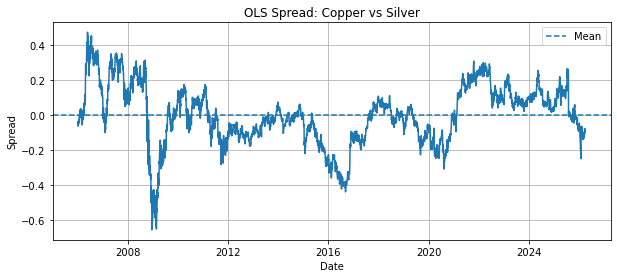

In [44]:
# -----------------------------
# 4. Plot OLS Spread
# -----------------------------

plt.figure(figsize=(10, 4))
plt.plot(metals_log.index.to_numpy(), metals_log["ols_spread"].to_numpy())
plt.axhline(metals_log["ols_spread"].to_numpy().mean(), linestyle="--", label="Mean")
plt.title("OLS Spread: Copper vs Silver")
plt.xlabel("Date")
plt.ylabel("Spread")
plt.legend()
plt.grid(True)
plt.show()

In [45]:
# ============================================================
# STEP 2 : KALMAN FILTER (NO LOOKAHEAD BIAS)
# ============================================================

y = metals_log["y_copper"]
x = metals_log["x_silver"]

# 1. BURN-IN: Calculate initial parameters using ONLY the first N days
BURN_IN = 252  # 1 trading year

# Ensure we have enough data for burn-in
if len(metals_log) <= BURN_IN:
    raise ValueError("Not enough data to support the specified burn-in period.")

x_burn = x.iloc[:BURN_IN]
y_burn = y.iloc[:BURN_IN]
X_burn_const = add_constant(x_burn)

ols_seed = OLS(y_burn, X_burn_const).fit()
alpha_init = ols_seed.params.iloc[0]
beta_init  = ols_seed.params.iloc[1]

print(f"Burn-in OLS initialized (first {BURN_IN} bars): alpha_0 = {alpha_init:.4f}, beta_0 = {beta_init:.4f}")

# 2. CONFIGURE FILTER
observation_matrices = np.vstack([
    np.ones(len(x)),
    x.values
]).T[:, np.newaxis, :]

delta = 5e-6
transition_covariance = delta / (1 - delta) * np.eye(2)

kf = KalmanFilter(
    n_dim_obs=1,
    n_dim_state=2,
    initial_state_mean=np.array([alpha_init, beta_init]), # Seeded strictly from burn-in
    initial_state_covariance=0.01 * np.eye(2),
    transition_matrices=np.eye(2),
    observation_matrices=observation_matrices,
    observation_covariance=0.001,
    transition_covariance=transition_covariance
)

# 3. FILTER (One-step-ahead causal)
state_means, state_covariances = kf.filter(y.values)

# 4. ASSIGN & MASK BURN-IN PERIOD
metals_log["kalman_alpha"] = state_means[:, 0]
metals_log["kalman_beta"] = state_means[:, 1]

metals_log["kalman_spread"] = (
    metals_log["y_copper"]
    - metals_log["kalman_alpha"]
    - metals_log["kalman_beta"] * metals_log["x_silver"]
)

# Mask the burn-in period to completely eliminate any lookahead leakage in signals
metals_log.loc[metals_log.index[:BURN_IN], ["kalman_alpha", "kalman_beta", "kalman_spread"]] = np.nan

print("\nKalman Spread (Out-of-Sample) Statistics:")
print(metals_log["kalman_spread"].dropna().describe())

Burn-in OLS initialized (first 252 bars): alpha_0 = 3.1361, beta_0 = 1.0559

Kalman Spread (Out-of-Sample) Statistics:
count    4859.000000
mean       -0.000099
std         0.021495
min        -0.183135
25%        -0.010134
50%         0.000244
75%         0.011160
max         0.107432
Name: kalman_spread, dtype: float64


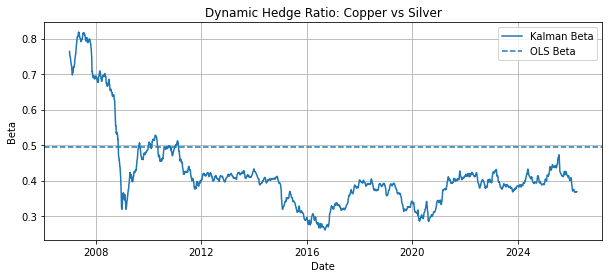

In [46]:
plt.figure(figsize=(10, 4))
plt.plot(metals_log.index.to_numpy(), metals_log["kalman_beta"].to_numpy(), label="Kalman Beta")
plt.axhline(beta_ols, linestyle="--", label="OLS Beta")
plt.title("Dynamic Hedge Ratio: Copper vs Silver")
plt.xlabel("Date")
plt.ylabel("Beta")
plt.legend()
plt.grid(True)
plt.show()

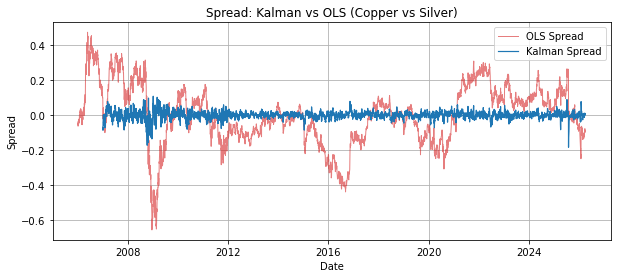

In [47]:
plt.figure(figsize=(10, 4))

plt.plot(metals_log.index.to_numpy(), metals_log["ols_spread"].to_numpy(), 
        label="OLS Spread", color="#D62728", alpha=0.6, lw=1.0)

plt.plot(metals_log.index.to_numpy(), metals_log["kalman_spread"].to_numpy(), 
        label="Kalman Spread", color="#1F77B4", lw=1.2)

plt.title("Spread: Kalman vs OLS (Copper vs Silver)")
plt.xlabel("Date")
plt.ylabel("Spread")
plt.legend()
plt.grid(True)
plt.show()

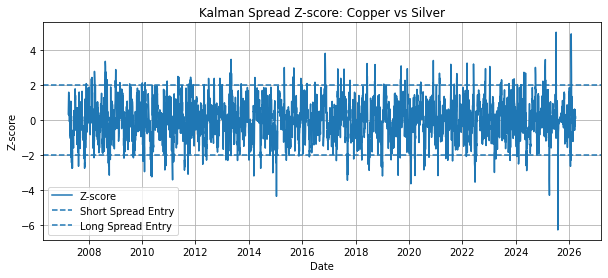

In [48]:
# ============================================================
# STEP 3: ROLLING Z-SCORE FOR MEAN REVERSION SIGNALS
# ============================================================

window = 60

metals_log["spread_mean"] = metals_log["kalman_spread"].rolling(window).mean()
metals_log["spread_std"] = metals_log["kalman_spread"].rolling(window).std()

metals_log["zscore"] = (
    metals_log["kalman_spread"] - metals_log["spread_mean"]
) / metals_log["spread_std"]

metals_log = metals_log.dropna()


plt.figure(figsize=(10, 4))
plt.plot(metals_log.index.to_numpy(), metals_log["zscore"].to_numpy(), label="Z-score")
plt.axhline(2, linestyle="--", label="Short Spread Entry")
plt.axhline(-2, linestyle="--", label="Long Spread Entry")
plt.title("Kalman Spread Z-score: Copper vs Silver")
plt.xlabel("Date")
plt.ylabel("Z-score")
plt.legend()
plt.grid(True)
plt.show()

════════════════════════════════════════════════════════════
  COPPER / SILVER — PERFORMANCE  (capital: $100,000)
════════════════════════════════════════════════════════════
  Total return           : +74.84%  →  $+74,842.59
  Annualised return      : +2.98%  →  $+2,977.33 / yr
  Annualised volatility  : 7.87%
  Sharpe ratio           : 0.3728
  Sortino ratio          : 0.2876
  Max drawdown           : -13.74%  →  $-13,744.17
  Time to recover MDD    : 1619 days
────────────────────────────────────────────────────────────
  Total trades           : 272
  Long  trades           : 136  (50.0%)
  Short trades           : 136  (50.0%)
  Hit ratio              : 66.2%
  Profit factor          : 1.57
  Avg trade duration     : 5.4 days
────────────────────────────────────────────────────────────
  Transaction costs (1bp): $1,990.61  (3.6% of gross)
════════════════════════════════════════════════════════════


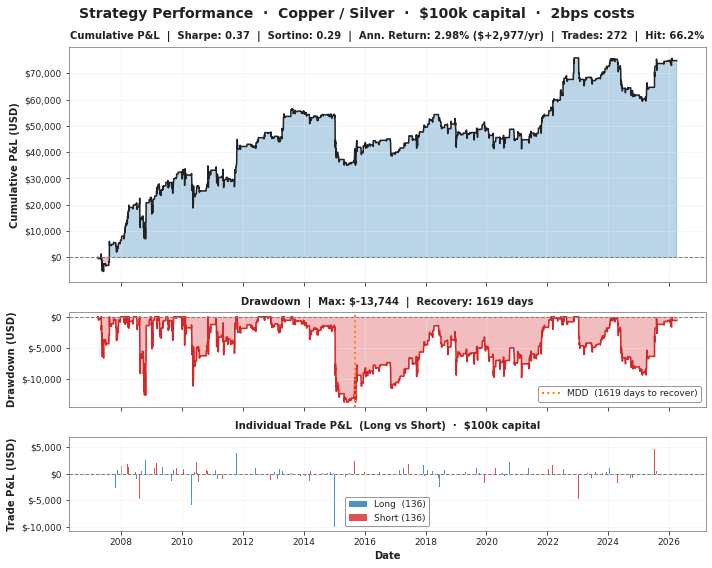

In [49]:
# ============================================================
# STEP 4: TRADING SIGNALS
# ============================================================
ENTRY_Z         = 1.5
EXIT_Z          = 0.5
INITIAL_CAPITAL = 100_000   # USD

metals_log["position"] = 0.0

# ── Scaled position sizing (proportional to z-score magnitude) ───────────────
MAX_SIZE = 1.0
MIN_SIZE = 0.1

z = metals_log["zscore"].values
pos = np.zeros(len(z))

for i in range(1, len(z)):
    prev = pos[i - 1]
    if np.isnan(z[i]):
        pos[i] = prev
        continue
    if prev == 0:
        if z[i] > ENTRY_Z:
            size = np.clip(MIN_SIZE + (z[i] - ENTRY_Z) / ENTRY_Z, MIN_SIZE, MAX_SIZE)
            pos[i] = -size                                  # short spread
        elif z[i] < -ENTRY_Z:
            size = np.clip(MIN_SIZE + (-z[i] - ENTRY_Z) / ENTRY_Z, MIN_SIZE, MAX_SIZE)
            pos[i] = size                                   # long spread
    else:
        pos[i] = 0 if abs(z[i]) < EXIT_Z else prev # exit or hold

metals_log["position"] = pos

# ============================================================
# STEP 5: STRATEGY RETURNS
# ============================================================
metals_log["copper_ret"] = metals_log["y_copper"].diff()
metals_log["silver_ret"] = metals_log["x_silver"].diff()

metals_log["spread_ret"] = (
    metals_log["copper_ret"]
    - metals_log["kalman_beta"].shift(1) * metals_log["silver_ret"]
)

metals_log["strategy_ret"] = (
    metals_log["position"].shift(1) * metals_log["spread_ret"]
).fillna(0)

# ============================================================
# STEP 6: TRANSACTION COSTS
# ============================================================
COST_PER_TRADE = 0.0001   # 1 bps per side

metals_log["trade"]            = metals_log["position"].diff().abs()
metals_log["transaction_cost"] = metals_log["trade"] * COST_PER_TRADE
metals_log["strategy_ret_net"] = metals_log["strategy_ret"] - metals_log["transaction_cost"]

# ============================================================
# STEP 7: PERFORMANCE METRICS
# ============================================================
ANN = 252

rets = metals_log["strategy_ret_net"].dropna()

# ── Core metrics ──────────────────────────────────────────────────────────────
cum_log          = rets.cumsum()
cumulative_ret   = np.exp(cum_log.iloc[-1]) - 1
total_pnl        = cumulative_ret * INITIAL_CAPITAL

ann_return       = np.exp(rets.mean() * ANN) - 1
ann_vol          = rets.std() * np.sqrt(ANN)
ann_pnl          = ann_return * INITIAL_CAPITAL
sharpe           = (rets.mean() / rets.std()) * np.sqrt(ANN)

downside         = rets[rets < 0]
sortino          = (rets.mean() / downside.std()) * np.sqrt(ANN)

# ── Drawdown + recovery ───────────────────────────────────────────────────────
cum_curve        = np.exp(cum_log)
running_max      = cum_curve.cummax()
drawdown_series  = (cum_curve - running_max) / running_max
max_dd           = drawdown_series.min()
max_dd_pnl       = max_dd * INITIAL_CAPITAL
mdd_idx          = drawdown_series.idxmin()

mdd_pos          = cum_curve.index.get_loc(mdd_idx)
peak_val         = running_max[mdd_idx]
recovery_bars    = np.nan
for j in range(mdd_pos, len(cum_curve)):
    if cum_curve.iloc[j] >= peak_val:
        recovery_bars = j - mdd_pos
        break
recovery_str = f"{recovery_bars:.0f} days" if not np.isnan(recovery_bars) else "not recovered"

# ── Trade-level analysis ──────────────────────────────────────────────────────
trade_log = []
i = 0
while i < len(pos):
    if pos[i] != 0:
        entry_i, entry_dir = i, pos[i]
        while i < len(pos) and pos[i] == entry_dir:
            i += 1
        exit_i    = i - 1
        trade_ret = rets.iloc[entry_i:exit_i + 1].sum()
        trade_log.append({
            "direction": "long" if entry_dir > 0 else "short",
            "entry":     metals_log.index[entry_i],
            "exit":      metals_log.index[exit_i],
            "duration":  exit_i - entry_i + 1,
            "return":    trade_ret,
            "pnl":       trade_ret * INITIAL_CAPITAL,
        })
    else:
        i += 1

trades_df      = pd.DataFrame(trade_log)
n_trades       = len(trades_df)
n_long         = (trades_df["direction"] == "long").sum()  if n_trades else 0
n_short        = (trades_df["direction"] == "short").sum() if n_trades else 0
hit_ratio      = (trades_df["return"] > 0).sum() / n_trades * 100 if n_trades else np.nan
avg_duration   = trades_df["duration"].mean() if n_trades else np.nan

gross_profit   = trades_df[trades_df["return"] > 0]["return"].sum() if n_trades else 0
gross_loss     = abs(trades_df[trades_df["return"] < 0]["return"].sum()) if n_trades else 0
profit_factor  = gross_profit / gross_loss if gross_loss > 0 else np.nan

total_costs     = metals_log["transaction_cost"].sum()
total_costs_usd = total_costs * INITIAL_CAPITAL
tc_pct          = total_costs / abs(cum_log.iloc[-1]) * 100 if cum_log.iloc[-1] != 0 else 0

# ── Print ─────────────────────────────────────────────────────────────────────
print("═" * 60)
print("  COPPER / SILVER — PERFORMANCE  (capital: $100,000)")
print("═" * 60)
print(f"  Total return           : {cumulative_ret:+.2%}  →  ${total_pnl:+,.2f}")
print(f"  Annualised return      : {ann_return:+.2%}  →  ${ann_pnl:+,.2f} / yr")
print(f"  Annualised volatility  : {ann_vol:.2%}")
print(f"  Sharpe ratio           : {sharpe:.4f}")
print(f"  Sortino ratio          : {sortino:.4f}")
print(f"  Max drawdown           : {max_dd:.2%}  →  ${max_dd_pnl:+,.2f}")
print(f"  Time to recover MDD    : {recovery_str}")
print("─" * 60)
print(f"  Total trades           : {n_trades}")
print((f"  Long  trades           : {n_long}  ({n_long/n_trades*100:.1f}%)") if n_trades else "  Long  trades : 0")
print((f"  Short trades           : {n_short}  ({n_short/n_trades*100:.1f}%)") if n_trades else "  Short trades : 0")
print(f"  Hit ratio              : {hit_ratio:.1f}%")
print(f"  Profit factor          : {profit_factor:.2f}")
print(f"  Avg trade duration     : {avg_duration:.1f} days")
print("─" * 60)
print(f"  Transaction costs (1bp): ${total_costs_usd:,.2f}  ({tc_pct:.1f}% of gross)")
print("═" * 60)

# ============================================================
# STEP 8: PERFORMANCE CHARTS (LIGHT THEME)
# ============================================================
import matplotlib.pyplot as plt

# ── Définition des couleurs claires ──────────────────────────────────────────
BG_WHITE = "#FFFFFF"
TEXT_BLACK = "#222222"
MAIN_BLUE = "#1F77B4"
ALERT_RED = "#D62728"
ACCENT_ORANGE = "#FF7F0E"
LINE_GRAY = "#7F7F7F"
GRID_GRAY = "#EAEAEA"

# ── Align cumulative curves back to the full index ────────────────────────────
dates_arr = metals_log.index.to_numpy()

cd        = ((np.exp(cum_log) - 1) * INITIAL_CAPITAL).reindex(metals_log.index).ffill().fillna(0)
dd_dollar = (drawdown_series * INITIAL_CAPITAL).reindex(metals_log.index).ffill().fillna(0)

cd_arr = cd.to_numpy()
dd_arr = dd_dollar.to_numpy()

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True,
                         gridspec_kw={"height_ratios": [2.5, 1, 1]})
fig.patch.set_facecolor(BG_WHITE)
fig.suptitle("Strategy Performance  ·  Copper / Silver  ·  $100k capital  ·  2bps costs",
             color=TEXT_BLACK, fontsize=14, fontweight="bold")

# — Panel 1 : Cumulative P&L —
ax1 = axes[0]
ax1.set_facecolor(BG_WHITE)
ax1.plot(dates_arr, cd_arr, color=TEXT_BLACK, lw=1.5)
ax1.fill_between(dates_arr, cd_arr, 0, where=(cd_arr >= 0), color=MAIN_BLUE, alpha=0.3)
ax1.fill_between(dates_arr, cd_arr, 0, where=(cd_arr <  0), color=ALERT_RED,  alpha=0.3)
ax1.axhline(0, color=LINE_GRAY, linestyle="--", lw=1.0)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:,.0f}"))
ax1.set_ylabel("Cumulative P&L (USD)", color=TEXT_BLACK, fontsize=10, fontweight="bold")
ax1.tick_params(colors=TEXT_BLACK, labelsize=9)
for sp in ax1.spines.values(): 
    sp.set_color(LINE_GRAY)
ax1.grid(True, alpha=0.5, color=GRID_GRAY)

ax1.set_title(
    f"Cumulative P&L  |  Sharpe: {sharpe:.2f}  |  Sortino: {sortino:.2f}  |  "
    f"Ann. Return: {ann_return:.2%} (${ann_pnl:+,.0f}/yr)  |  "
    f"Trades: {n_trades}  |  Hit: {hit_ratio:.1f}%",
    color=TEXT_BLACK, fontsize=10, fontweight="bold", pad=8)

# — Panel 2 : Drawdown —
ax2 = axes[1]
ax2.set_facecolor(BG_WHITE)
ax2.fill_between(dates_arr, dd_arr, 0, color=ALERT_RED, alpha=0.3)
ax2.plot(dates_arr, dd_arr, color=ALERT_RED, lw=1.5)
ax2.axhline(0, color=LINE_GRAY, linestyle="--", lw=1.0)
ax2.axvline(dates_arr[mdd_pos] if mdd_pos < len(dates_arr) else dates_arr[-1], 
            color=ACCENT_ORANGE, linestyle=":", lw=2.0,
            label=f"MDD  ({recovery_str} to recover)")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:,.0f}"))
ax2.set_ylabel("Drawdown (USD)", color=TEXT_BLACK, fontsize=10, fontweight="bold")
ax2.tick_params(colors=TEXT_BLACK, labelsize=9)
for sp in ax2.spines.values(): 
    sp.set_color(LINE_GRAY)
ax2.grid(True, alpha=0.5, color=GRID_GRAY)
ax2.legend(fontsize=9, facecolor=BG_WHITE, edgecolor=LINE_GRAY, labelcolor=TEXT_BLACK)

ax2.set_title(f"Drawdown  |  Max: ${max_dd_pnl:,.0f}  |  Recovery: {recovery_str}",
              color=TEXT_BLACK, fontsize=10, fontweight="bold", pad=8)

# — Panel 3 : Individual trade P&L —
ax3 = axes[2]
ax3.set_facecolor(BG_WHITE)
if n_trades:
    long_t  = trades_df[trades_df["direction"] == "long"]
    short_t = trades_df[trades_df["direction"] == "short"]
    ax3.bar(long_t["entry"],  long_t["pnl"],  color=MAIN_BLUE, width=4, alpha=0.8, label=f"Long  ({n_long})")
    ax3.bar(short_t["entry"], short_t["pnl"], color=ALERT_RED,  width=4, alpha=0.8, label=f"Short ({n_short})")
ax3.axhline(0, color=LINE_GRAY, linestyle="--", lw=1.0)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:,.0f}"))
ax3.set_ylabel("Trade P&L (USD)", color=TEXT_BLACK, fontsize=10, fontweight="bold")
ax3.set_xlabel("Date", color=TEXT_BLACK, fontsize=10, fontweight="bold")
ax3.tick_params(colors=TEXT_BLACK, labelsize=9)
for sp in ax3.spines.values(): 
    sp.set_color(LINE_GRAY)
ax3.grid(True, alpha=0.5, color=GRID_GRAY)
ax3.legend(fontsize=9, facecolor=BG_WHITE, edgecolor=LINE_GRAY, labelcolor=TEXT_BLACK)

ax3.set_title("Individual Trade P&L  (Long vs Short)  ·  $100k capital",
            color=TEXT_BLACK, fontsize=10, fontweight="bold", pad=8)

plt.tight_layout()
plt.show()

**Agricultural Sector**

  ★  Best Agriculture pair  →  W1  /  SO1
     p-value = 0.000581  |  Score = 0.9994


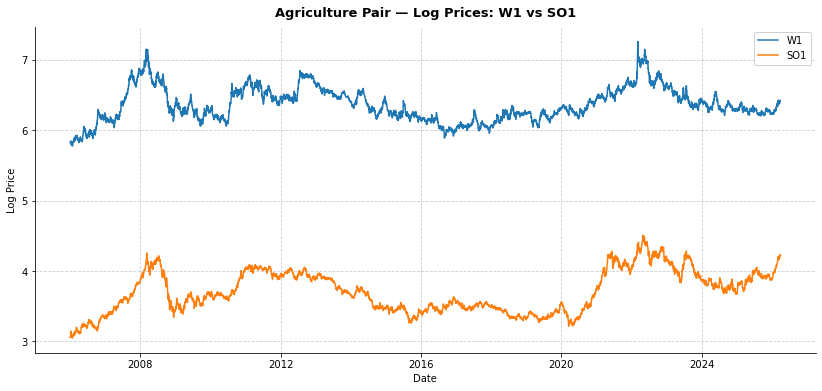

In [50]:

# ═══════════════════════════════════════════════════════════════════════════
#  Best Agriculture Pair: Price Chart
# ═══════════════════════════════════════════════════════════════════════════

# ── 1. Pick best agriculture pair from the scan  ─────────────────
agri_results = results_all["Agriculture"].reset_index(drop=True)
best_agri    = agri_results.iloc[0]
T1, T2       = best_agri["Pair"].split(" / ")

print(f"  ★  Best Agriculture pair  →  {T1}  /  {T2}")
print(f"     p-value = {best_agri['p-value']:.6f}  |  Score = {best_agri['Score']:.4f}")

# ── 2. Extract log-price series ────────────────────────────────────────────
s1 = log_px[T1].dropna()
s2 = log_px[T2].dropna()
idx = s1.index.intersection(s2.index)
s1, s2 = s1.loc[idx], s2.loc[idx]

# ── 3. Plot (single chart) ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6), facecolor="white")

BLUE  = "#1f77b4"
ORNG  = "#ff7f0e"

ax.plot(s1.index.to_numpy(), s1.to_numpy(),
        color=BLUE, linewidth=1.5, label=T1)

ax.plot(s2.index.to_numpy(), s2.to_numpy(),
        color=ORNG, linewidth=1.5, label=T2)

ax.set_title(f"Agriculture Pair — Log Prices: {T1} vs {T2}",
        fontsize=13, fontweight="bold", pad=10)

ax.set_xlabel("Date", fontsize=10)
ax.set_ylabel("Log Price", fontsize=10)

ax.legend(fontsize=10, framealpha=0.9)
ax.grid(True, linestyle="--", alpha=0.4, color="grey")

ax.spines[["top", "right"]].set_visible(False)
ax.set_facecolor("white")

plt.show()

In [51]:

# ═══════════════════════════════════════════════════════════════════════════
# Static OLS  (full-sample, log prices)
#            y = alpha_ols + beta_ols * x + ε
# ═══════════════════════════════════════════════════════════════════════════
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

y_arr = s1.values          # dependent  (T1)
x_arr = s2.values          # independent (T2)
dates = idx

X_const   = add_constant(x_arr)
ols_model = OLS(y_arr, X_const).fit()

alpha_ols = ols_model.params[0]
beta_ols  = ols_model.params[1]
r2        = ols_model.rsquared

print("=" * 50)
print("  OLS Results  (full-sample, log prices)")
print("=" * 50)
print(f"  α  (intercept) = {alpha_ols:+.6f}")
print(f"  β  (hedge ratio)= {beta_ols:+.6f}")
print()

# ── OLS residual (spread) ──────────────────────────────────────────────────
resid_ols = y_arr - (alpha_ols + beta_ols * x_arr)

print(f"  Spread stats (OLS residual):")
print(f"  mean = {resid_ols.mean():.6f}  |  std = {resid_ols.std():.6f}")
print(f"  min  = {resid_ols.min():.6f}  |  max = {resid_ols.max():.6f}")
print()





  OLS Results  (full-sample, log prices)
  α  (intercept) = +4.004633
  β  (hedge ratio)= +0.636182

  Spread stats (OLS residual):
  mean = -0.000000  |  std = 0.146001
  min  = -0.395195  |  max = 0.524794



In [52]:

# ═══════════════════════════════════════════════════════════════════════════
#  Kalman Filter  (no look-ahead bias)
#
#  Strategy to avoid look-ahead bias:
#    1. BURN-IN  : OLS on the first `BURN_IN` bars → seeds β₀, α₀
#    2. FILTER   : pykalman.filter() is already one-step-ahead causal
#    3. MASK     : first BURN_IN estimates are discarded from signals
#
#  State vector  θₜ = [βₜ, αₜ]  (hedge ratio + intercept)
#  Observation   yₜ = [xₜ  1] · θₜ + vₜ      vₜ ~ N(0, R)
#  Transition    θₜ = θₜ₋₁ + wₜ               wₜ ~ N(0, Q)
#    Q = δ/(1-δ) · I   (random-walk state noise)
# ═══════════════════════════════════════════════════════════════════════════
from pykalman import KalmanFilter
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

# ── Parameters ──────────────────────────────────────────────────────────────
BURN_IN       = 252       # 1 trading year used to seed the filter
DELTA         = 5e-5      # state noise — controls β adaptation speed
OBS_NOISE_VAR = 5e-3      # observation noise variance

n = len(y_arr)

# ── Step 1: OLS seed on burn-in window ─────────────────────────────────────
X_burn    = add_constant(x_arr[:BURN_IN])
ols_seed  = OLS(y_arr[:BURN_IN], X_burn).fit()
beta_seed = ols_seed.params[1]
alpha_seed= ols_seed.params[0]

print(f"  Burn-in OLS seed  ({BURN_IN} bars)")
print(f"  β₀ = {beta_seed:.4f}  |  α₀ = {alpha_seed:.4f}")

# ── Step 2: Build Kalman Filter ─────────────────────────────────────────────
Q        = DELTA / (1 - DELTA) * np.eye(2)          # state transition cov
obs_mat  = np.column_stack([x_arr, np.ones(n)])[:, np.newaxis, :]  # (n,1,2)

kf = KalmanFilter(
    n_dim_obs   = 1,
    n_dim_state = 2,
    initial_state_mean       = [beta_seed, alpha_seed],
    initial_state_covariance = np.ones((2, 2)),
    transition_matrices      = np.eye(2),             # random walk
    observation_matrices     = obs_mat,
    observation_covariance   = [[OBS_NOISE_VAR]],
    transition_covariance    = Q,
)

# ── Step 3: Forward filter (one-step-ahead — no look-ahead bias) ─────────────
state_means, state_covs = kf.filter(y_arr[:, np.newaxis])

beta_kf  = state_means[:, 0]    # dynamic hedge ratio
alpha_kf = state_means[:, 1]    # dynamic intercept

# ── Step 4: Kalman spread ────────────────────────────────────────────────────
spread_kf = y_arr - (alpha_kf + beta_kf * x_arr)

# ── Step 5: Rolling Z-score (avoids look-ahead in normalisation) ─────────────
ROLL = 252
spread_s   = pd.Series(spread_kf, index=dates)
roll_mean  = spread_s.rolling(ROLL, min_periods=30).mean()
roll_std   = spread_s.rolling(ROLL, min_periods=30).std()
z_score_kf = ((spread_s - roll_mean) / roll_std)

# ── Mask burn-in period ──────────────────────────────────────────────────────
beta_kf_live   = beta_kf.copy().astype(float)
beta_kf_live[:BURN_IN] = np.nan

spread_kf_live = spread_kf.copy().astype(float)
spread_kf_live[:BURN_IN] = np.nan

z_live = z_score_kf.copy()
z_live.iloc[:BURN_IN] = np.nan

print(f"\n  Kalman filter run on {n} bars  |  DELTA={DELTA}  OBS_NOISE={OBS_NOISE_VAR}")
print(f"  β range (post burn-in): [{np.nanmin(beta_kf_live):.4f}, {np.nanmax(beta_kf_live):.4f}]")
print(f"  β final: {beta_kf[-1]:.4f}   α final: {alpha_kf[-1]:.4f}")




  Burn-in OLS seed  (252 bars)
  β₀ = 1.2268  |  α₀ = 2.0416

  Kalman filter run on 5113 bars  |  DELTA=5e-05  OBS_NOISE=0.005
  β range (post burn-in): [0.4064, 1.2839]
  β final: 0.4241   α final: 4.6200


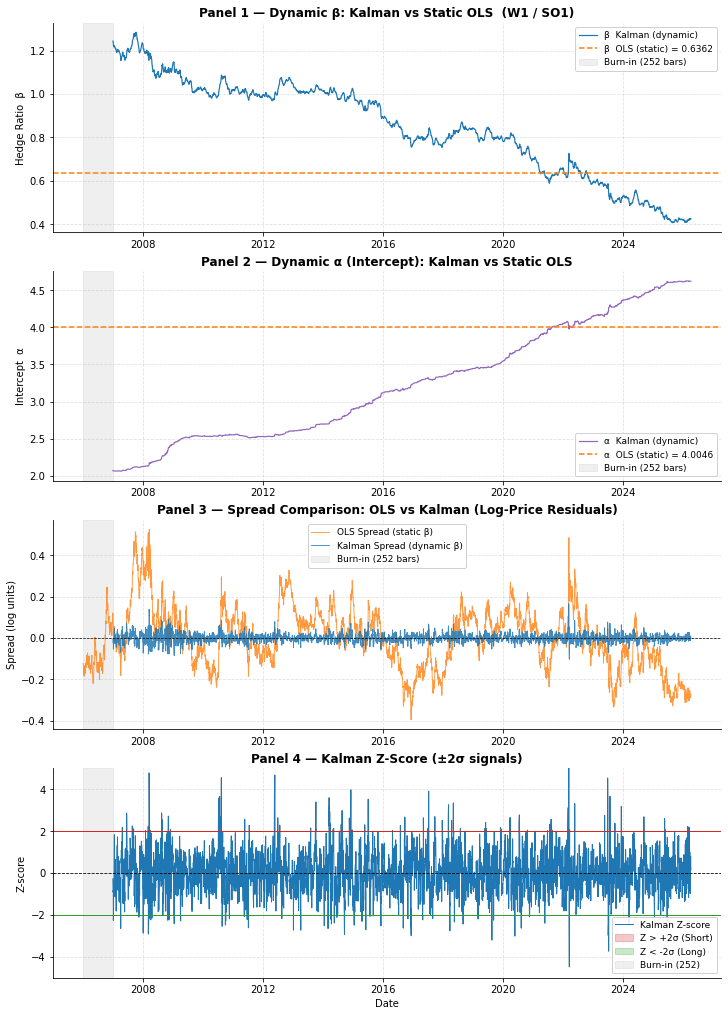

In [53]:

# ═══════════════════════════════════════════════════════════════════════════
# Analysis Dashboard  (4 panels, white background)
#
#  Panel 1 : Dynamic β (Kalman) vs static β (OLS)
#  Panel 2 : Kalman α (intercept) through time
#  Panel 3 : Residual / Spread comparison — OLS vs Kalman
#  Panel 4 : Z-score of Kalman spread  (±1σ, ±2σ bands)
# ═══════════════════════════════════════════════════════════════════════════

BLUE   = "#1f77b4"
ORNG   = "#ff7f0e"
GREEN  = "#2ca02c"
RED    = "#d62728"
GREY   = "#aaaaaa"
PURPLE = "#9467bd"

dates_np = dates.to_numpy()

fig, axes = plt.subplots(4, 1, figsize=(10, 14),
                        facecolor="white", constrained_layout=True)

# ─── Panel 1 : β Kalman vs β OLS ──────────────────────────────────────────
ax = axes[0]
ax.plot(dates_np, beta_kf_live, color=BLUE,  linewidth=1.2, label="β  Kalman (dynamic)")
ax.axhline(beta_ols,         color=ORNG,  linewidth=1.5, linestyle="--",
        label=f"β  OLS (static) = {beta_ols:.4f}")
ax.axvspan(dates_np[0], dates_np[BURN_IN - 1],
        color="grey", alpha=0.12, label=f"Burn-in ({BURN_IN} bars)")
ax.set_facecolor("white")
ax.set_title(f"Panel 1 — Dynamic β: Kalman vs Static OLS  ({T1} / {T2})",
        fontsize=12, fontweight="bold", pad=6)
ax.set_ylabel("Hedge Ratio  β", fontsize=10)
ax.legend(fontsize=9, framealpha=0.9)
ax.grid(True, linestyle="--", alpha=0.35, color=GREY)
ax.spines[["top", "right"]].set_visible(False)

# ─── Panel 2 : α Kalman through time ──────────────────────────────────────
ax = axes[1]
alpha_kf_live = alpha_kf.copy().astype(float)
alpha_kf_live[:BURN_IN] = np.nan
ax.plot(dates_np, alpha_kf_live, color=PURPLE, linewidth=1.2, label="α  Kalman (dynamic)")
ax.axhline(alpha_ols, color=ORNG, linewidth=1.5, linestyle="--",
        label=f"α  OLS (static) = {alpha_ols:.4f}")
ax.axvspan(dates_np[0], dates_np[BURN_IN - 1],
        color="grey", alpha=0.12, label=f"Burn-in ({BURN_IN} bars)")
ax.set_facecolor("white")
ax.set_title("Panel 2 — Dynamic α (Intercept): Kalman vs Static OLS",
        fontsize=12, fontweight="bold", pad=6)
ax.set_ylabel("Intercept  α", fontsize=10)
ax.legend(fontsize=9, framealpha=0.9)
ax.grid(True, linestyle="--", alpha=0.35, color=GREY)
ax.spines[["top", "right"]].set_visible(False)

# ─── Panel 3 : Residual comparison OLS vs Kalman ─────────────────────────
ax = axes[2]
ax.plot(dates_np, resid_ols,          color=ORNG, linewidth=0.9,
        alpha=0.8, label="OLS Spread (static β)")
ax.plot(dates_np, spread_kf_live,     color=BLUE, linewidth=0.9,
        alpha=0.85, label="Kalman Spread (dynamic β)")
ax.axhline(0, color="black", linewidth=0.7, linestyle="--")
ax.axvspan(dates_np[0], dates_np[BURN_IN - 1],
        color="grey", alpha=0.12, label=f"Burn-in ({BURN_IN} bars)")
ax.set_facecolor("white")
ax.set_title("Panel 3 — Spread Comparison: OLS vs Kalman (Log-Price Residuals)",
        fontsize=12, fontweight="bold", pad=6)
ax.set_ylabel("Spread (log units)", fontsize=10)
ax.legend(fontsize=9, framealpha=0.9)
ax.grid(True, linestyle="--", alpha=0.35, color=GREY)
ax.spines[["top", "right"]].set_visible(False)

# ─── Panel 4 : Z-score (clean) ──────────────────────────────────────
ax = axes[3]

# convert once (fixes your error)
z_dates = z_live.index.to_numpy()
z_vals  = z_live.to_numpy()

# Z-score line
ax.plot(z_dates, z_vals, color=BLUE, linewidth=1.0,
        label="Kalman Z-score")

# ±2σ signal zones
ax.fill_between(z_dates, 2, z_vals,
                where=(z_vals >= 2),
                color=RED, alpha=0.25,
                label="Z > +2σ (Short)")

ax.fill_between(z_dates, -2, z_vals,
                where=(z_vals <= -2),
                color=GREEN, alpha=0.25,
                label="Z < -2σ (Long)")

# key reference lines only
ax.axhline(2,  color=RED,   linewidth=1.0)
ax.axhline(-2, color=GREEN, linewidth=1.0)
ax.axhline(0,  color="black", linestyle="--", linewidth=0.8)

# burn-in shading
ax.axvspan(dates_np[0], dates_np[BURN_IN - 1],
        color="grey", alpha=0.12,
        label=f"Burn-in ({BURN_IN})")

# styling
ax.set_title("Panel 4 — Kalman Z-Score (±2σ signals)",
        fontsize=12, fontweight="bold")
ax.set_ylabel("Z-score", fontsize=10)
ax.set_xlabel("Date", fontsize=10)
ax.set_ylim(-5, 5)

ax.legend(fontsize=9, framealpha=0.9)
ax.grid(True, linestyle="--", alpha=0.35, color=GREY)
ax.spines[["top", "right"]].set_visible(False)


  Long  entries : 124
  Short entries : 151
  Exits         : 275
  Total changes : 550


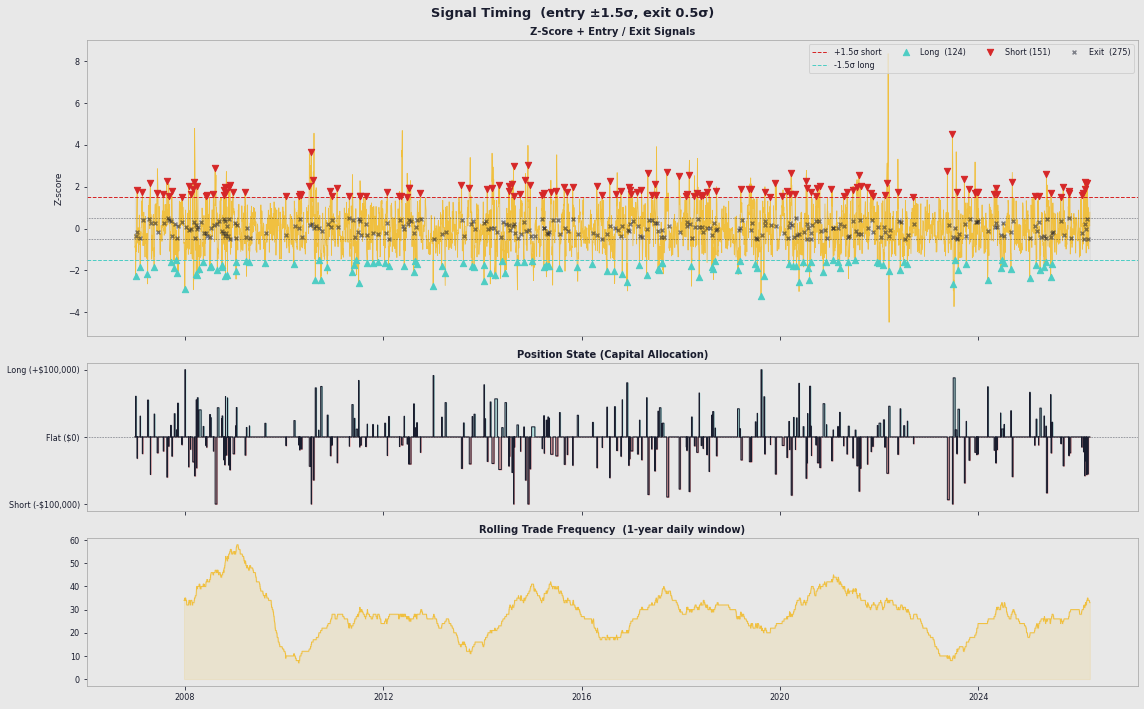

In [54]:
# ─────────────────────────────────────────────────────────────────────────────
#  PLOT 3 — Long / Short signals from Kalman z-score (Budget Scaled)
# ─────────────────────────────────────────────────────────────────────────────

# ── Signal parameters ─────────────────────────────────────────────────────────
ENTRY_Z = 1.5   # z-score threshold to enter a position
EXIT_Z  = 0.5   # z-score threshold to exit a position

# ── Slice to post-burn-in period (no look-ahead) ─────────────────────────────
zscore_kf  = z_live.iloc[BURN_IN:]

# CORRECTION ICI : On convertit immédiatement en tableaux NumPy 1D purs
dates_test = dates[BURN_IN:].to_numpy()
z_arr = np.squeeze(zscore_kf.to_numpy())

# ── Position sizing — scaled by z-score magnitude & Budget ───────────────────
BUDGET = 100_000  # Total allocation capital
MAX_SIZE = 1.0    # maximum position fraction (1 = fully invested)
MIN_SIZE = 0.1    # minimum size once entry threshold is crossed

position = np.zeros(len(z_arr))
for i in range(1, len(z_arr)):
    prev = position[i-1]

    if np.isnan(z_arr[i]):
        continue

    if prev == 0:                                       # flat → look for entry
        if z_arr[i] > ENTRY_Z:
            raw_size = (z_arr[i] - ENTRY_Z) / ENTRY_Z
            fraction = np.clip(MIN_SIZE + raw_size, MIN_SIZE, MAX_SIZE)
            position[i] = -fraction * BUDGET            # short allocation
        elif z_arr[i] < -ENTRY_Z:
            raw_size = (-z_arr[i] - ENTRY_Z) / ENTRY_Z
            fraction = np.clip(MIN_SIZE + raw_size, MIN_SIZE, MAX_SIZE)
            position[i] = fraction * BUDGET             # long allocation
        else:
            position[i] = 0
    else:                                               # in position → look for exit
        if abs(z_arr[i]) < EXIT_Z:
            position[i] = 0                             # exit
        else:
            position[i] = prev                          # hold same dollar size

# ── Trade counting ────────────────────────────────────────────────────────────
changes = np.diff(position, prepend=0)

shifted_pos = np.roll(position, 1)
shifted_pos[0] = 0

is_long_entry  = (shifted_pos == 0) & (position > 0)
is_short_entry = (shifted_pos == 0) & (position < 0)
is_exit        = (shifted_pos != 0) & (position == 0)

long_entries  = np.where(is_long_entry)[0]
short_entries = np.where(is_short_entry)[0]
exits         = np.where(is_exit)[0]

print(f"  Long  entries : {len(long_entries)}")
print(f"  Short entries : {len(short_entries)}")
print(f"  Exits         : {len(exits)}")
print(f"  Total changes : {np.sum(changes != 0)}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True,
                        gridspec_kw={"height_ratios": [2, 1, 1]})
fig.patch.set_facecolor(WHITE)

# J'ai retiré T1 et T2 du titre si tu ne les as pas définis, sinon remets-les
fig.suptitle(f"Signal Timing  (entry ±{ENTRY_Z}σ, exit {EXIT_Z}σ)",
            color=PANEL, fontsize=13, fontweight="bold")

# — Panel 1 : z-score + markers —
ax1 = axes[0]
ax1.set_facecolor(WHITE)
ax1.plot(dates_test, z_arr, color=GOLD, lw=0.8, zorder=2)
ax1.axhline( ENTRY_Z, color=RED,  linestyle="--", lw=1.0, label=f"+{ENTRY_Z}σ short")
ax1.axhline(-ENTRY_Z, color=CYAN,  linestyle="--", lw=1.0, label=f"-{ENTRY_Z}σ long")
ax1.axhline( EXIT_Z,  color=PANEL, linestyle=":",  lw=0.6)
ax1.axhline(-EXIT_Z,  color=PANEL, linestyle=":",  lw=0.6)
ax1.fill_between(dates_test, -ENTRY_Z, ENTRY_Z, color=PANEL, alpha=0.03)

ax1.scatter(dates_test[long_entries],  z_arr[long_entries],
            color=CYAN, marker="^", s=40, zorder=3, label=f"Long  ({len(long_entries)})")
ax1.scatter(dates_test[short_entries], z_arr[short_entries],
            color=RED,  marker="v", s=40, zorder=3, label=f"Short ({len(short_entries)})")
ax1.scatter(dates_test[exits],         z_arr[exits],
            color=PANEL, marker="x", s=15, zorder=3, label=f"Exit  ({len(exits)})", alpha=0.5)

ax1.set_ylabel("Z-score", color=PANEL, fontsize=9)
ax1.tick_params(colors=PANEL, labelsize=8)
for sp in ax1.spines.values(): sp.set_color(GREY)
ax1.legend(fontsize=8, facecolor=WHITE, labelcolor=PANEL, ncol=4, loc="upper right")
ax1.set_title("Z-Score + Entry / Exit Signals", color=PANEL, fontsize=10, fontweight="bold", pad=5)

# — Panel 2 : position state —
ax2 = axes[1]
ax2.set_facecolor(WHITE)
ax2.plot(dates_test, position, color=PANEL, lw=1.0, drawstyle="steps-post")
pos_long  = np.where(position > 0, position, 0)
pos_short = np.where(position < 0, position, 0)
ax2.fill_between(dates_test, pos_long,  0, color=CYAN, alpha=0.3, step="post")
ax2.fill_between(dates_test, pos_short, 0, color=RED,  alpha=0.3, step="post")
ax2.axhline(0, color=PANEL, lw=0.6, linestyle=":")

ax2.set_yticks([-BUDGET, 0, BUDGET])
ax2.set_yticklabels([f"Short (-${BUDGET:,})", "Flat ($0)", f"Long (+${BUDGET:,})"], color=WHITE, fontsize=8)

ax2.tick_params(colors=PANEL, labelsize=8)
for sp in ax2.spines.values(): sp.set_color(GREY)
ax2.set_title("Position State (Capital Allocation)", color=PANEL, fontsize=10, fontweight="bold", pad=5)

# — Panel 3 : rolling trade count (daily data → 252-bar = 1 year) —
ax3 = axes[2]
ax3.set_facecolor(WHITE)

# On utilise index=dates_test qui est maintenant un array 1D
change_series  = pd.Series((changes != 0).astype(int))
rolling_trades = change_series.rolling(252).sum()          # 1 trading year (daily)

ax3.plot(dates_test, rolling_trades.to_numpy(), color=GOLD, lw=1.0)
ax3.fill_between(dates_test, rolling_trades.to_numpy(), color=GOLD, alpha=0.15)
ax3.set_ylabel("Trades / year", color=WHITE, fontsize=9)
ax3.tick_params(colors=PANEL, labelsize=8)
for sp in ax3.spines.values(): sp.set_color(GREY)
ax3.set_title("Rolling Trade Frequency  (1-year daily window)",
            color=PANEL, fontsize=10, fontweight="bold", pad=5)

plt.tight_layout()
plt.show()

════════════════════════════════════════════════════════════
  STRATEGY PERFORMANCE METRICS  (capital: $100,000)
════════════════════════════════════════════════════════════
  Total return           : +0.3891  →  $+38,907.07
  Annualised return      : 2.02%  →  $+2,016.99 / yr
  Annualised volatility  : 9.53%
  Sharpe ratio           : 0.2116
  Sortino ratio          : 0.1346
  Max drawdown           : -0.3521  →  $-35,206.62
  Time to recover MDD    : not recovered
────────────────────────────────────────────────────────────
  Total trades           : 275
  Long  trades           : 124  (45.1%)
  Short trades           : 151  (54.9%)
  Hit ratio              : 35.6%
  Profit factor          : 0.47
  Avg trade duration     : 3.8 days
────────────────────────────────────────────────────────────
  Transaction costs (1bp): 0.0550  →  $5,500.00  (14.1% of gross)
════════════════════════════════════════════════════════════


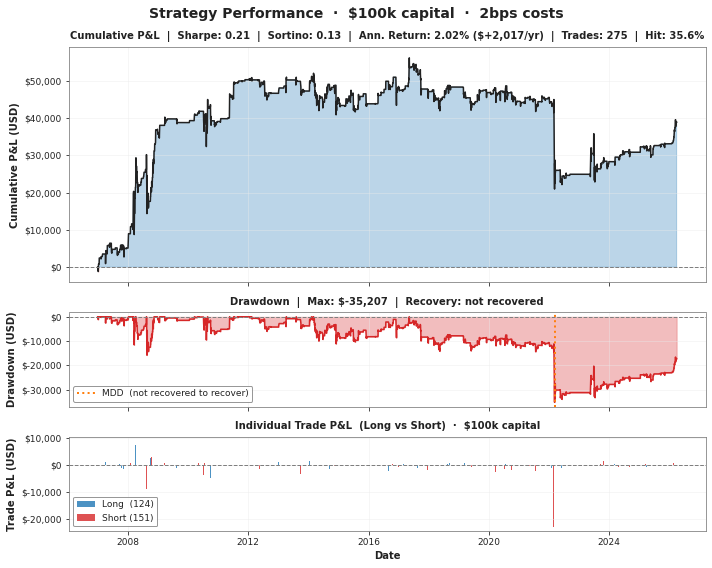

In [55]:
# ─────────────────────────────────────────────────────────────────────────────
#  PERFORMANCE METRICS  (daily data · $100,000 initial capital)
# ─────────────────────────────────────────────────────────────────────────────

INITIAL_CAPITAL = 100_000          # starting budget in USD

# ── Time index (post-burn-in, daily) ─────────────────────────────────────────
# dates_test and position already defined in Plot 3 cell
ANN            = 252               # annualisation factor for daily bars
COST_PER_TRADE = 0.0001            # 2 bps per side

# ── Transaction costs at every position change ────────────────────────────────
changes_arr       = np.diff(position, prepend=0)
changes_series    = pd.Series(changes_arr, index=dates_test)
transaction_costs = (changes_series != 0).astype(float) * COST_PER_TRADE

# ── Spread returns: position(t-1) × Δspread(t), net of costs ─────────────────
y_test = y_arr[BURN_IN:]
x_test = x_arr[BURN_IN:]

ret_y = np.diff(y_test, prepend=0)
ret_x = np.diff(x_test, prepend=0)

# Shift beta by 1 bar to avoid look-ahead (trade t with beta known at t-1)
beta_shifted    = np.roll(beta_kf, 1)
beta_shifted[0] = beta_kf[0]
beta_test       = beta_shifted[BURN_IN:]

true_port_ret  = ret_y - (beta_test * ret_x)

# On divise la position par INITIAL_CAPITAL pour revenir en % et éviter le capital au carré
position_weights = pd.Series(position, index=dates_test) / INITIAL_CAPITAL

strategy_ret   = position_weights.shift(1).fillna(0) * true_port_ret
strategy_ret   = strategy_ret - transaction_costs

# ── Cumulative PnL (log-return units + dollar equivalent) ────────────────────
cumulative_ret    = strategy_ret.cumsum()
cumulative_dollar = cumulative_ret * INITIAL_CAPITAL

# ── Annualised metrics ────────────────────────────────────────────────────────
total_return  = cumulative_ret.iloc[-1]
total_pnl     = total_return * INITIAL_CAPITAL

ann_return    = strategy_ret.mean() * ANN
ann_vol       = strategy_ret.std()  * np.sqrt(ANN)
ann_pnl       = ann_return * INITIAL_CAPITAL
sharpe        = ann_return / ann_vol if ann_vol > 0 else np.nan

downside      = strategy_ret[strategy_ret < 0]
downside_std  = downside.std() * np.sqrt(ANN)
sortino       = ann_return / downside_std if downside_std > 0 else np.nan

# ── Max drawdown ──────────────────────────────────────────────────────────────
roll_max     = cumulative_ret.cummax()
drawdown     = cumulative_ret - roll_max
max_drawdown = drawdown.min()
max_dd_pnl   = max_drawdown * INITIAL_CAPITAL
mdd_idx      = drawdown.idxmin()

mdd_pos       = cumulative_ret.index.get_loc(mdd_idx)
peak_val      = roll_max[mdd_idx]
recovery_bars = np.nan
for j in range(mdd_pos, len(cumulative_ret)):
    if cumulative_ret.iloc[j] >= peak_val:
        recovery_bars = j - mdd_pos
        break
recovery_str = f"{recovery_bars:.0f} days" if not np.isnan(recovery_bars) else "not recovered"

# ── Trade-level analysis ──────────────────────────────────────────────────────
trade_log = []
i = 0
while i < len(position):
    if position[i] != 0:
        entry_i   = i
        entry_dir = position[i]
        while i < len(position) and position[i] == entry_dir:
            i += 1
        exit_i    = i - 1
        trade_ret = strategy_ret.iloc[entry_i:exit_i+1].sum()
        trade_log.append({
            "direction": "long" if entry_dir > 0 else "short",
            "entry":     dates_test[entry_i],
            "exit":      dates_test[exit_i],
            "duration":  exit_i - entry_i + 1,
            "return":    trade_ret,
            "pnl":       trade_ret * INITIAL_CAPITAL,
        })
    else:
        i += 1

trades_df      = pd.DataFrame(trade_log)
n_trades       = len(trades_df)
n_long_trades  = (trades_df["direction"] == "long").sum()  if n_trades else 0
n_short_trades = (trades_df["direction"] == "short").sum() if n_trades else 0

winning_trades  = (trades_df["return"] > 0).sum() if n_trades else 0
hit_ratio       = winning_trades / n_trades * 100 if n_trades > 0 else np.nan
avg_duration    = trades_df["duration"].mean() if n_trades else np.nan

gross_profit    = trades_df[trades_df["return"] > 0]["return"].sum() if n_trades else 0
gross_loss      = abs(trades_df[trades_df["return"] < 0]["return"].sum()) if n_trades else 0
profit_factor   = gross_profit / gross_loss if gross_loss > 0 else np.nan
total_costs     = transaction_costs.sum()
total_costs_usd = total_costs * INITIAL_CAPITAL

# ── Print ─────────────────────────────────────────────────────────────────────
print("═" * 60)
print("  STRATEGY PERFORMANCE METRICS  (capital: $100,000)")
print("═" * 60)
print(f"  Total return           : {total_return:+.4f}  →  ${total_pnl:+,.2f}")
print(f"  Annualised return      : {ann_return:.2%}  →  ${ann_pnl:+,.2f} / yr")
print(f"  Annualised volatility  : {ann_vol:.2%}")
print(f"  Sharpe ratio           : {sharpe:.4f}")
print(f"  Sortino ratio          : {sortino:.4f}")
print(f"  Max drawdown           : {max_drawdown:.4f}  →  ${max_dd_pnl:+,.2f}")
print(f"  Time to recover MDD    : {recovery_str}")
print("─" * 60)
print(f"  Total trades           : {n_trades}")
print(f"  Long  trades           : {n_long_trades}  ({n_long_trades/n_trades*100:.1f}%)" if n_trades else "  Long  trades : 0")
print(f"  Short trades           : {n_short_trades}  ({n_short_trades/n_trades*100:.1f}%)" if n_trades else "  Short trades : 0")
print(f"  Hit ratio              : {hit_ratio:.1f}%")
print(f"  Profit factor          : {profit_factor:.2f}")
print(f"  Avg trade duration     : {avg_duration:.1f} days")
print("─" * 60)
tc_pct = total_costs / abs(total_return) * 100 if total_return != 0 else 0
print(f"  Transaction costs (1bp): {total_costs:.4f}  →  ${total_costs_usd:,.2f}  ({tc_pct:.1f}% of gross)")
print("═" * 60)

# ── Plot (PRESENTATION LIGHT THEME) ───────────────────────────────────────────

# Couleurs haut contraste pour la lisibilité
BG_WHITE = "#FFFFFF"
TEXT_BLACK = "#222222"
MAIN_BLUE = "#1F77B4"
ALERT_RED = "#D62728"
ACCENT_ORANGE = "#FF7F0E"
LINE_GRAY = "#7F7F7F"
GRID_GRAY = "#EAEAEA"

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True,
                        gridspec_kw={"height_ratios": [2.5, 1, 1]})
fig.patch.set_facecolor(BG_WHITE)
fig.suptitle(f"Strategy Performance  ·  $100k capital  ·  2bps costs",
            color=TEXT_BLACK, fontsize=14, fontweight="bold")

# — Panel 1 : Cumulative P&L in dollars —
ax1 = axes[0]
ax1.set_facecolor(BG_WHITE)
cd = cumulative_dollar.to_numpy()

ax1.plot(dates_test, cd, color=TEXT_BLACK, lw=1.5) # Ligne principale bien noire
ax1.fill_between(dates_test, cd, 0, where=(cd >= 0), color=MAIN_BLUE, alpha=0.3)
ax1.fill_between(dates_test, cd, 0, where=(cd <  0), color=ALERT_RED,  alpha=0.3)
ax1.axhline(0, color=LINE_GRAY, linestyle="--", lw=1.0)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:,.0f}"))
ax1.set_ylabel("Cumulative P&L (USD)", color=TEXT_BLACK, fontsize=10, fontweight="bold")
ax1.tick_params(colors=TEXT_BLACK, labelsize=9)
for sp in ax1.spines.values(): 
    sp.set_color(LINE_GRAY)
ax1.grid(True, alpha=0.5, color=GRID_GRAY)

ax1.set_title(
    f"Cumulative P&L  |  Sharpe: {sharpe:.2f}  |  Sortino: {sortino:.2f}  |  "
    f"Ann. Return: {ann_return:.2%} (${ann_pnl:+,.0f}/yr)  |  "
    f"Trades: {n_trades}  |  Hit: {hit_ratio:.1f}%",
    color=TEXT_BLACK, fontsize=10, fontweight="bold", pad=8)

# — Panel 2 : Drawdown in dollars —
ax2 = axes[1]
ax2.set_facecolor(BG_WHITE)
dd = (drawdown * INITIAL_CAPITAL).to_numpy()

ax2.fill_between(dates_test, dd, 0, color=ALERT_RED, alpha=0.3)
ax2.plot(dates_test, dd, color=ALERT_RED, lw=1.5)
ax2.axhline(0, color=LINE_GRAY, linestyle="--", lw=1.0)
ax2.axvline(mdd_idx, color=ACCENT_ORANGE, linestyle=":", lw=2.0,
            label=f"MDD  ({recovery_str} to recover)")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:,.0f}"))
ax2.set_ylabel("Drawdown (USD)", color=TEXT_BLACK, fontsize=10, fontweight="bold")
ax2.tick_params(colors=TEXT_BLACK, labelsize=9)
for sp in ax2.spines.values(): 
    sp.set_color(LINE_GRAY)
ax2.grid(True, alpha=0.5, color=GRID_GRAY)
ax2.legend(fontsize=9, facecolor=BG_WHITE, edgecolor=LINE_GRAY, labelcolor=TEXT_BLACK)

ax2.set_title(
    f"Drawdown  |  Max: ${max_dd_pnl:,.0f}  |  Recovery: {recovery_str}",
    color=TEXT_BLACK, fontsize=10, fontweight="bold", pad=8)

# — Panel 3 : Individual trade P&L in dollars —
ax3 = axes[2]
ax3.set_facecolor(BG_WHITE)
if n_trades:
    long_t  = trades_df[trades_df["direction"] == "long"]
    short_t = trades_df[trades_df["direction"] == "short"]
    ax3.bar(long_t["entry"],  long_t["pnl"],  color=MAIN_BLUE, width=4, alpha=0.8,
            label=f"Long  ({n_long_trades})")
    ax3.bar(short_t["entry"], short_t["pnl"], color=ALERT_RED,  width=4, alpha=0.8,
            label=f"Short ({n_short_trades})")
ax3.axhline(0, color=LINE_GRAY, linestyle="--", lw=1.0)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:,.0f}"))
ax3.set_ylabel("Trade P&L (USD)", color=TEXT_BLACK, fontsize=10, fontweight="bold")
ax3.set_xlabel("Date", color=TEXT_BLACK, fontsize=10, fontweight="bold")
ax3.tick_params(colors=TEXT_BLACK, labelsize=9)
for sp in ax3.spines.values(): 
    sp.set_color(LINE_GRAY)
ax3.grid(True, alpha=0.5, color=GRID_GRAY)
ax3.legend(fontsize=9, facecolor=BG_WHITE, edgecolor=LINE_GRAY, labelcolor=TEXT_BLACK)

ax3.set_title("Individual Trade P&L  (Long vs Short)  ·  $100k capital",
            color=TEXT_BLACK, fontsize=10, fontweight="bold", pad=8)

plt.tight_layout()
plt.show()